### Initial Imports and Data Splits

In [74]:
# import statements --> SOME OF THESE MAY NOT BE NEEDED
%matplotlib inline 
import numpy as np 

from matplotlib import pyplot as plt 
from matplotlib.cm import get_cmap
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import MultipleLocator
#from matplotlib.ticker import MaxNLocator
#import matplotlib.gridspec as gridspec
#import matplotlib.colors as mcolors
#import colorcet as cc
#from matplotlib.patches import Rectangle, FancyArrowPatch
#import matplotlib.ticker as ticker
#from mpl_toolkits.mplot3d import Axes3D
#from mpl_toolkits.axes_grid1 import make_axes_locatable
#import mpl_scatter_density
#from astropy.visualization import LogStretch
#from astropy.visualization.mpl_normalize import ImageNormalize

#import h5py

#from astropy.io import fits,ascii,votable
#from astropy import units as u 
#from astropy import constants as const
#from astropy import table
#from astropy.cosmology import Planck15,FlatLambdaCDM
#from astropy.table import Table

#from sklearn.cluster import KMeans
#from sklearn import mixture
#from itertools import combinations
#from sklearn.neighbors import KNeighborsRegressor
#from sklearn.utils import check_array
#from sklearn.neighbors._base import _get_weights
#imports for TWO-NN
#import scipy
from sklearn import neighbors
#from sklearn import preprocessing

#import scipy.integrate
#from scipy.integrate import quad
#import numba
#from sklearn.datasets import load_digits
import umap
import umap.plot
from umap.umap_ import nearest_neighbors
import pandas as pd
#import plotly
import plotly.express as px

#imports for plotly graphing
#import plotly.graph_objects as go
#from plotly.subplots import make_subplots

import pickle

pd.set_option('display.max_columns', None)

#BRETT NOTEBOOK IMPORTS
from pathlib import Path

from importlib import reload
import utils
reload(utils)
from minisom import MiniSom

# imports from animation_simplified2 notebook
import seaborn as sns
sns.set(style='white', rc={'figure.figsize':(14, 12), 'animation.html': 'html5'})
import os
import copy

In [3]:
import umapz2

In [9]:
data = pd.read_parquet('som_embeddings_manhattan_260507.parquet')
data

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOM_69_138_s0.85_lr0.68-1,SOM_69_138_s0.85_lr0.68-2,SOM_69_138_s0.85_lr0.8-1,SOM_69_138_s0.85_lr0.8-2,SOM_69_138_s0.85_lr0.92-1,SOM_69_138_s0.85_lr0.92-2,SOM_69_138_s1_lr0.68-1,SOM_69_138_s1_lr0.68-2,SOM_69_138_s1_lr0.8-1,SOM_69_138_s1_lr0.8-2,SOM_69_138_s1_lr0.92-1,SOM_69_138_s1_lr0.92-2,SOM_69_138_s1.15_lr0.68-1,SOM_69_138_s1.15_lr0.68-2,SOM_69_138_s1.15_lr0.8-1,SOM_69_138_s1.15_lr0.8-2,SOM_69_138_s1.15_lr0.92-1,SOM_69_138_s1.15_lr0.92-2,SOM_75_150_s0.85_lr0.68-1,SOM_75_150_s0.85_lr0.68-2,SOM_75_150_s0.85_lr0.8-1,SOM_75_150_s0.85_lr0.8-2,SOM_75_150_s0.85_lr0.92-1,SOM_75_150_s0.85_lr0.92-2,SOM_75_150_s1_lr0.68-1,SOM_75_150_s1_lr0.68-2,SOM_75_150_s1_lr0.8-1,SOM_75_150_s1_lr0.8-2,SOM_75_150_s1_lr0.92-1,SOM_75_150_s1_lr0.92-2,SOM_75_150_s1.15_lr0.68-1,SOM_75_150_s1.15_lr0.68-2,SOM_75_150_s1.15_lr0.8-1,SOM_75_150_s1.15_lr0.8-2,SOM_75_150_s1.15_lr0.92-1,SOM_75_150_s1.15_lr0.92-2,SOM_80_160_s0.85_lr0.68-1,SOM_80_160_s0.85_lr0.68-2,SOM_80_160_s0.85_lr0.8-1,SOM_80_160_s0.85_lr0.8-2,SOM_80_160_s0.85_lr0.92-1,SOM_80_160_s0.85_lr0.92-2,SOM_80_160_s1_lr0.68-1,SOM_80_160_s1_lr0.68-2,SOM_80_160_s1_lr0.8-1,SOM_80_160_s1_lr0.8-2,SOM_80_160_s1_lr0.92-1,SOM_80_160_s1_lr0.92-2,SOM_80_160_s1.15_lr0.68-1,SOM_80_160_s1.15_lr0.68-2,SOM_80_160_s1.15_lr0.8-1,SOM_80_160_s1.15_lr0.8-2,SOM_80_160_s1.15_lr0.92-1,SOM_80_160_s1.15_lr0.92-2
7,12,150.476809,2.331511,0,0.432424,0.006043,0.017385,0.367684,0.004799,0.013929,0.539085,0.006673,0.012705,0.913139,0.006940,0.008187,0.995689,0.010382,0.011179,1.010389,0.021430,0.021652,1.176385,0.018240,0.016771,1.238664,0.023098,0.021265,1.273614,0.031158,0.026693,0.793401,0.012663,0.021113,0.623383,0.011264,0.024039,0.7070,0,NaN,30,0.00,5,9.048000e+08,0.1,1,-17.59872,-18.85507,-18.93651,8.69380,8.65194,8.74706,8.64422,-0.18369,-8.815,24.810225,24.986313,24.570856,23.998658,23.904690,23.888779,23.723626,23.667616,23.637405,24.151268,24.413112,-0.176089,0.415457,0.572198,0.093968,0.015911,0.165153,0.056011,0,129,0,12,13,80,43,11,28,10,43,10,47,116,56,53,34,124,62,69,74,29,38,8,56,125,53,128,64,68,53,110,11,147,13,126,43,80,12,108,4,95,43,89,69,27,3,100,48,89,27,156,67,99
39,73,149.468025,1.625609,0,1.057806,0.006321,0.007477,1.301316,0.007003,0.005769,2.870638,0.011023,0.003954,3.669017,0.012785,0.003763,4.321371,0.018494,0.004597,5.147967,0.045866,0.009110,5.366495,0.022263,0.004492,5.903986,0.031370,0.006063,6.666023,0.046399,0.007598,4.142945,0.036884,0.011779,4.426406,0.054762,0.016462,0.4290,0,NaN,30,0.34,9,1.609000e+09,0.2,1,-17.40718,-19.16920,-19.50800,9.06086,9.01925,9.10800,9.01447,0.08064,-8.977,23.838985,23.614043,22.755054,22.488626,22.310946,22.120911,22.075773,21.972137,21.840333,22.356727,22.284872,0.224942,0.858989,0.266428,0.177680,0.190035,0.045137,0.103637,35,25,26,6,59,49,30,2,60,52,46,99,21,4,38,7,31,16,29,111,70,131,24,26,26,18,29,63,48,62,61,127,45,65,34,56,74,19,28,84,24,96,16,88,16,91,20,83,16,84,44,105,77,17
40,74,150.488035,1.875422,0,0.941051,0.003713,0.004937,1.032136,0.004159,0.004320,1.066959,0.005443,0.005254,1.123350,0.005748,0.005525,1.208387,0.008979,0.007981,1.734654,0.019518,0.011504,2.413042,0.014805,0.006643,2.547439,0.017875,0.008007,2.257407,0.024673,0.0119

In [10]:
#data = pd.read_parquet('som_embeddings2M_260409.parquet')
spec95 = pd.read_parquet('spec95_ugrizyJH_maps_250819.parquet')
spec95 = spec95.drop(columns=['SOM-1', 'SOM-2', 'UMAP3D-1', 'UMAP3D-2', 'UMAP3D-3'])
spec95 = spec95[spec95['specz']>0.0]
spec95 = pd.merge(left=spec95[['ID', 'specz']], right=data, left_on='ID', right_on='ID')
spec95

,ID,specz,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOM_69_138_s0.85_lr0.68-1,SOM_69_138_s0.85_lr0.68-2,SOM_69_138_s0.85_lr0.8-1,SOM_69_138_s0.85_lr0.8-2,SOM_69_138_s0.85_lr0.92-1,SOM_69_138_s0.85_lr0.92-2,SOM_69_138_s1_lr0.68-1,SOM_69_138_s1_lr0.68-2,SOM_69_138_s1_lr0.8-1,SOM_69_138_s1_lr0.8-2,SOM_69_138_s1_lr0.92-1,SOM_69_138_s1_lr0.92-2,SOM_69_138_s1.15_lr0.68-1,SOM_69_138_s1.15_lr0.68-2,SOM_69_138_s1.15_lr0.8-1,SOM_69_138_s1.15_lr0.8-2,SOM_69_138_s1.15_lr0.92-1,SOM_69_138_s1.15_lr0.92-2,SOM_75_150_s0.85_lr0.68-1,SOM_75_150_s0.85_lr0.68-2,SOM_75_150_s0.85_lr0.8-1,SOM_75_150_s0.85_lr0.8-2,SOM_75_150_s0.85_lr0.92-1,SOM_75_150_s0.85_lr0.92-2,SOM_75_150_s1_lr0.68-1,SOM_75_150_s1_lr0.68-2,SOM_75_150_s1_lr0.8-1,SOM_75_150_s1_lr0.8-2,SOM_75_150_s1_lr0.92-1,SOM_75_150_s1_lr0.92-2,SOM_75_150_s1.15_lr0.68-1,SOM_75_150_s1.15_lr0.68-2,SOM_75_150_s1.15_lr0.8-1,SOM_75_150_s1.15_lr0.8-2,SOM_75_150_s1.15_lr0.92-1,SOM_75_150_s1.15_lr0.92-2,SOM_80_160_s0.85_lr0.68-1,SOM_80_160_s0.85_lr0.68-2,SOM_80_160_s0.85_lr0.8-1,SOM_80_160_s0.85_lr0.8-2,SOM_80_160_s0.85_lr0.92-1,SOM_80_160_s0.85_lr0.92-2,SOM_80_160_s1_lr0.68-1,SOM_80_160_s1_lr0.68-2,SOM_80_160_s1_lr0.8-1,SOM_80_160_s1_lr0.8-2,SOM_80_160_s1_lr0.92-1,SOM_80_160_s1_lr0.92-2,SOM_80_160_s1.15_lr0.68-1,SOM_80_160_s1.15_lr0.68-2,SOM_80_160_s1.15_lr0.8-1,SOM_80_160_s1.15_lr0.8-2,SOM_80_160_s1.15_lr0.92-1,SOM_80_160_s1.15_lr0.92-2
0,535,0.82589,150.726526,1.795723,0,3.135322,0.004911,0.001979,3.543392,0.005600,0.001707,4.149280,0.006839,0.001707,5.531073,0.006686,0.001311,9.094858,0.011055,0.001310,6.137582,0.023292,0.003891,8.654985,0.055195,0.006917,8.847195,0.061729,0.007971,10.089081,0.037653,0.004077,12.819075,0.017958,0.001854,8.697933,0.024042,0.003679,0.8165,0,NaN,28,1.85,8,1.609000e+08,0.2,1,-20.28363,-21.12927,-21.52369,9.31240,9.27122,9.34644,9.33645,1.23468,-8.087,22.659295,22.526452,22.355068,22.042977,21.503010,21.930007,21.556834,21.532986,21.390371,21.130358,21.551460,0.132843,0.171384,0.312092,0.539966,-0.426997,0.373173,0.023848,8,15,8,15,19,80,2,58,13,14,65,51,35,133,11,133,56,72,10,53,54,66,53,67,50,62,68,63,18,145,69,64,71,60,33,116,63,89,13,142,23,146,21,148,11,145,19,136,12,144,62,120,12,144
1,670,1.16549,149.730259,1.959835,0,1.941518,0.005379,0.003476,1.863746,0.004178,0.002408,2.359093,0.005581,0.002440,3.347864,0.005832,0.001883,4.712861,0.009339,0.002130,5.044670,0.019908,0.004038,5.936375,0.013675,0.002495,7.337306,0.017588,0.002736,9.483263,0.026426,0.003042,13.707825,0.014322,0.001382,12.806878,0.012845,0.001335,1.1792,0,NaN,30,1.02,10,2.273000e+08,0.3,0,-20.49749,-21.89549,-22.47231,9.79095,9.75692,9.83047,9.80739,1.80017,-7.953,23.179647,23.224033,22.968137,22.588081,22.216789,22.142918,21.966197,21.736158,21.457606,21.057579,21.131392,-0.044386,0.255896,0.380057,0.371292,0.073870,0.176721,0.230038,19,135,27,108,18,90,54,92,53,96,50,94,24,127,2,116,30,113,38,46,28,45,40,11,40,1,10,44,54,106,60,136,67,109,52,118,67,97,46,83,48,11,20,6,58,30,65,116,61,25,6,7,44,150
2,692,0.30572,149.642181,2.379960,0,1.315313,0.006756,0.006467,4.484449,0.005892,0.001415,13.213070,0.007819,0.000612,24.048380,0.008534,0.000384,35.020987,0.013526,0.000416,40.134805,0.026583,0.000678,66.579523,0.061359,0.000999,9

In [11]:
data

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOM_69_138_s0.85_lr0.68-1,SOM_69_138_s0.85_lr0.68-2,SOM_69_138_s0.85_lr0.8-1,SOM_69_138_s0.85_lr0.8-2,SOM_69_138_s0.85_lr0.92-1,SOM_69_138_s0.85_lr0.92-2,SOM_69_138_s1_lr0.68-1,SOM_69_138_s1_lr0.68-2,SOM_69_138_s1_lr0.8-1,SOM_69_138_s1_lr0.8-2,SOM_69_138_s1_lr0.92-1,SOM_69_138_s1_lr0.92-2,SOM_69_138_s1.15_lr0.68-1,SOM_69_138_s1.15_lr0.68-2,SOM_69_138_s1.15_lr0.8-1,SOM_69_138_s1.15_lr0.8-2,SOM_69_138_s1.15_lr0.92-1,SOM_69_138_s1.15_lr0.92-2,SOM_75_150_s0.85_lr0.68-1,SOM_75_150_s0.85_lr0.68-2,SOM_75_150_s0.85_lr0.8-1,SOM_75_150_s0.85_lr0.8-2,SOM_75_150_s0.85_lr0.92-1,SOM_75_150_s0.85_lr0.92-2,SOM_75_150_s1_lr0.68-1,SOM_75_150_s1_lr0.68-2,SOM_75_150_s1_lr0.8-1,SOM_75_150_s1_lr0.8-2,SOM_75_150_s1_lr0.92-1,SOM_75_150_s1_lr0.92-2,SOM_75_150_s1.15_lr0.68-1,SOM_75_150_s1.15_lr0.68-2,SOM_75_150_s1.15_lr0.8-1,SOM_75_150_s1.15_lr0.8-2,SOM_75_150_s1.15_lr0.92-1,SOM_75_150_s1.15_lr0.92-2,SOM_80_160_s0.85_lr0.68-1,SOM_80_160_s0.85_lr0.68-2,SOM_80_160_s0.85_lr0.8-1,SOM_80_160_s0.85_lr0.8-2,SOM_80_160_s0.85_lr0.92-1,SOM_80_160_s0.85_lr0.92-2,SOM_80_160_s1_lr0.68-1,SOM_80_160_s1_lr0.68-2,SOM_80_160_s1_lr0.8-1,SOM_80_160_s1_lr0.8-2,SOM_80_160_s1_lr0.92-1,SOM_80_160_s1_lr0.92-2,SOM_80_160_s1.15_lr0.68-1,SOM_80_160_s1.15_lr0.68-2,SOM_80_160_s1.15_lr0.8-1,SOM_80_160_s1.15_lr0.8-2,SOM_80_160_s1.15_lr0.92-1,SOM_80_160_s1.15_lr0.92-2
7,12,150.476809,2.331511,0,0.432424,0.006043,0.017385,0.367684,0.004799,0.013929,0.539085,0.006673,0.012705,0.913139,0.006940,0.008187,0.995689,0.010382,0.011179,1.010389,0.021430,0.021652,1.176385,0.018240,0.016771,1.238664,0.023098,0.021265,1.273614,0.031158,0.026693,0.793401,0.012663,0.021113,0.623383,0.011264,0.024039,0.7070,0,NaN,30,0.00,5,9.048000e+08,0.1,1,-17.59872,-18.85507,-18.93651,8.69380,8.65194,8.74706,8.64422,-0.18369,-8.815,24.810225,24.986313,24.570856,23.998658,23.904690,23.888779,23.723626,23.667616,23.637405,24.151268,24.413112,-0.176089,0.415457,0.572198,0.093968,0.015911,0.165153,0.056011,0,129,0,12,13,80,43,11,28,10,43,10,47,116,56,53,34,124,62,69,74,29,38,8,56,125,53,128,64,68,53,110,11,147,13,126,43,80,12,108,4,95,43,89,69,27,3,100,48,89,27,156,67,99
39,73,149.468025,1.625609,0,1.057806,0.006321,0.007477,1.301316,0.007003,0.005769,2.870638,0.011023,0.003954,3.669017,0.012785,0.003763,4.321371,0.018494,0.004597,5.147967,0.045866,0.009110,5.366495,0.022263,0.004492,5.903986,0.031370,0.006063,6.666023,0.046399,0.007598,4.142945,0.036884,0.011779,4.426406,0.054762,0.016462,0.4290,0,NaN,30,0.34,9,1.609000e+09,0.2,1,-17.40718,-19.16920,-19.50800,9.06086,9.01925,9.10800,9.01447,0.08064,-8.977,23.838985,23.614043,22.755054,22.488626,22.310946,22.120911,22.075773,21.972137,21.840333,22.356727,22.284872,0.224942,0.858989,0.266428,0.177680,0.190035,0.045137,0.103637,35,25,26,6,59,49,30,2,60,52,46,99,21,4,38,7,31,16,29,111,70,131,24,26,26,18,29,63,48,62,61,127,45,65,34,56,74,19,28,84,24,96,16,88,16,91,20,83,16,84,44,105,77,17
40,74,150.488035,1.875422,0,0.941051,0.003713,0.004937,1.032136,0.004159,0.004320,1.066959,0.005443,0.005254,1.123350,0.005748,0.005525,1.208387,0.008979,0.007981,1.734654,0.019518,0.011504,2.413042,0.014805,0.006643,2.547439,0.017875,0.008007,2.257407,0.024673,0.0119

In [4]:
#spec95.to_parquet('umap_embeddings_spec.parquet')

In [12]:
splits = umapz2.data_split(photcat=data, speccat=spec95, valid_size=len(spec95), rs=41)

In [13]:
valid = splits['valid'].copy()
valid

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOM_69_138_s0.85_lr0.68-1,SOM_69_138_s0.85_lr0.68-2,SOM_69_138_s0.85_lr0.8-1,SOM_69_138_s0.85_lr0.8-2,SOM_69_138_s0.85_lr0.92-1,SOM_69_138_s0.85_lr0.92-2,SOM_69_138_s1_lr0.68-1,SOM_69_138_s1_lr0.68-2,SOM_69_138_s1_lr0.8-1,SOM_69_138_s1_lr0.8-2,SOM_69_138_s1_lr0.92-1,SOM_69_138_s1_lr0.92-2,SOM_69_138_s1.15_lr0.68-1,SOM_69_138_s1.15_lr0.68-2,SOM_69_138_s1.15_lr0.8-1,SOM_69_138_s1.15_lr0.8-2,SOM_69_138_s1.15_lr0.92-1,SOM_69_138_s1.15_lr0.92-2,SOM_75_150_s0.85_lr0.68-1,SOM_75_150_s0.85_lr0.68-2,SOM_75_150_s0.85_lr0.8-1,SOM_75_150_s0.85_lr0.8-2,SOM_75_150_s0.85_lr0.92-1,SOM_75_150_s0.85_lr0.92-2,SOM_75_150_s1_lr0.68-1,SOM_75_150_s1_lr0.68-2,SOM_75_150_s1_lr0.8-1,SOM_75_150_s1_lr0.8-2,SOM_75_150_s1_lr0.92-1,SOM_75_150_s1_lr0.92-2,SOM_75_150_s1.15_lr0.68-1,SOM_75_150_s1.15_lr0.68-2,SOM_75_150_s1.15_lr0.8-1,SOM_75_150_s1.15_lr0.8-2,SOM_75_150_s1.15_lr0.92-1,SOM_75_150_s1.15_lr0.92-2,SOM_80_160_s0.85_lr0.68-1,SOM_80_160_s0.85_lr0.68-2,SOM_80_160_s0.85_lr0.8-1,SOM_80_160_s0.85_lr0.8-2,SOM_80_160_s0.85_lr0.92-1,SOM_80_160_s0.85_lr0.92-2,SOM_80_160_s1_lr0.68-1,SOM_80_160_s1_lr0.68-2,SOM_80_160_s1_lr0.8-1,SOM_80_160_s1_lr0.8-2,SOM_80_160_s1_lr0.92-1,SOM_80_160_s1_lr0.92-2,SOM_80_160_s1.15_lr0.68-1,SOM_80_160_s1.15_lr0.68-2,SOM_80_160_s1.15_lr0.8-1,SOM_80_160_s1.15_lr0.8-2,SOM_80_160_s1.15_lr0.92-1,SOM_80_160_s1.15_lr0.92-2
682744,888967,149.936450,2.785401,0,0.482169,0.008109,0.021217,0.556797,0.004353,0.008433,0.649724,0.005866,0.009340,0.815287,0.006075,0.008074,1.022175,0.009601,0.010115,1.516981,0.023160,0.015645,2.479349,0.054714,0.023929,3.181551,0.075771,0.027204,3.775385,0.057224,0.016556,5.577980,0.014766,0.003503,6.055261,0.017200,0.003780,1.5429,0,NaN,27,0.99,5,1.139000e+09,0.2,0,-19.84784,-21.53190,-22.12276,10.02579,9.89337,10.08403,10.03590,1.14004,-8.917,24.692001,24.535758,24.368177,24.121724,23.876187,23.447549,22.914156,22.643403,22.457597,22.033808,21.944668,0.156243,0.167580,0.246453,0.245537,0.428638,0.533394,0.270753,61,12,17,103,65,9,61,135,66,10,63,2,60,12,64,15,7,103,69,76,60,40,38,138,72,61,41,142,37,143,41,138,72,78,32,148,47,32,65,114,20,2,9,14,67,111,39,68,71,114,74,144,49,128
705718,915989,150.389923,1.791782,0,0.300923,0.003346,0.013912,0.391560,0.003238,0.008863,0.729946,0.004244,0.005987,0.857738,0.004264,0.005368,0.908493,0.006994,0.008269,1.053736,0.015095,0.014646,1.133205,0.028540,0.027268,1.063807,0.038095,0.040864,1.151679,0.027239,0.025818,0.553292,0.012940,0.030942,0.312715,0.016622,0.070726,0.4445,0,NaN,30,0.00,1,3.210000e+08,0.0,0,-16.35030,-17.63879,-17.70557,8.08427,8.02849,8.19774,8.06536,-1.17000,-9.212,25.203863,24.918003,24.241773,24.066614,24.004195,23.843171,23.764228,23.832843,23.746671,24.542615,25.162128,0.285860,0.676230,0.175160,0.062418,0.161025,0.078942,-0.068615,43,10,44,23,61,59,34,8,60,58,24,4,31,10,39,121,6,109,18,27,71,132,13,135,17,13,33,53,32,33,65,124,53,77,4,106,73,32,74,36,33,95,36,94,10,87,45,102,8,82,50,97,42,104
132564,175014,150.121155,1.644934,0,0.281661,0.003567,0.015858,0.294709,0.003148,0.011457,0.385362,0.004180,0.011174,0.606247,0.004185,0.007456,0.866615,0.006661,0.008258,0.800703,0.015264,0.019495,0.987316,0.013438,0.014739,0.996477,0.017941,

### SOM Uncertainty Quantification Procedure:
We have determined through qualitative and quantitative considerations that the best SOM 
is of size (50,100), sigma=1.0, and learning_rate=0.8 (more details in Appendix). Since
none of these were unambiguous or obvious best choices among the ranges of values tested, 
we use +/-15% of each value as a "reasonable range" from which to calculate the uncertainty
associated with choice of these parameters.
The uncertainties associated with these parameters will be calculated using the five-fold 
crossvalidation test on the validation data only. The uncertainties associated with these 
three choices will be the range of mean values, divided by 2. The uncertainty for each parameter will be
computed while holding the other parameters constant.

The uncertainties associated with the random seed used in generating the SOM embeddings
and with the finite size of the test dataset will be calculated using the real train and test 
samples rather than the validation sample. This is because these sources of uncertainty have 
nothing to do with our choices of hyperparameters and therefore the results of this testing
cannot "contaminate" our findings or hyperparameter choices in any way. This is identical to
the treatment of these uncertainty sources in the UMAP case.


1. Uncertainty associated with SOM size choice, with fixed learning_rate and sigma.

2. Uncertainty associated with sigma choice, with fixed size and learning_rate.

3. Uncertainty associated with learning_rate choice, with fixed size and sigma.

4. Uncertainty associated with random seed variations. Mean and standard deviations of 
   performance metrics calculated using 25 random seeds with fixed SOM parameters.
    
5. Uncertainty due to finite test data can be calculated with 10-25 bootstrap samples of 
   the size of the test set, with replacement. Measure all statistics and look at 
   standard deviation in redshift bins. This is for fixed SOM parameters and random seed.

Based on our testing, the best SOM size is (50,100). Taking a range of +/-15% of area (number of cells) gives SOMs with dimensions (46,92) and (54,108). For this calculation we'll hold the sigma and learning_rate values at 1 and 0.8.

### uncertainty due to SOM size optimization

In [14]:
#sizes = [(46,92), (50,100), (54,108)]
sizes = [(69,138), (75,150), (80,160)]
size_b_sets = {str(size): [0] for size in sizes}
size_b_results = {str(size): [0] for size in sizes}

size_b_outliers_mean = []
size_b_nmads_mean = []
size_b_biases_mean = []

for size in sizes:
    size_b_results[str(size)], size_b_sets[str(size)] = umapz2.crossvalidate_binned(folds=5, data=valid, nn=size[0], 
                            map='SOM_'+str(size[0])+'_'+str(size[1])+'_s1_lr0.8', tv='lp_photoz', dim=2, rematch=True)
    size_b_outliers_mean.append(size_b_results[str(size)]['outliers_mean'])
    size_b_nmads_mean.append(size_b_results[str(size)]['nmads_mean'])
    size_b_biases_mean.append(size_b_results[str(size)]['biases_mean'])

unc_size_outliers = (np.asarray(size_b_outliers_mean).max(axis=0) - np.asarray(size_b_outliers_mean).min(axis=0))/2
unc_size_nmads = (np.asarray(size_b_nmads_mean).max(axis=0) - np.asarray(size_b_nmads_mean).min(axis=0))/2
unc_size_biases = (np.asarray(size_b_biases_mean).max(axis=0) - np.asarray(size_b_biases_mean).min(axis=0))/2

Here I'll take the half the range of means for each metric (f_out, nmad, bias) in each redshift bin as the uncertainty due to k-value choice in that bin. We could alternatively incorporate the ranges into this calculation, but I will leave it this way for now --> FOLLOW UP

In [15]:
size_binned_results = {
'bin_centers':size_b_results['(75, 150)']['bin_centers'],
'outliers_mean':size_b_results['(75, 150)']['outliers_mean'],
'nmads_mean':size_b_results['(75, 150)']['nmads_mean'],
'biases_mean':size_b_results['(75, 150)']['biases_mean'],
'unc_size_outliers':unc_size_outliers,
'unc_size_nmads':unc_size_nmads,
'unc_size_biases':unc_size_biases
}

The following plot contains the mean metrics when using k=15 in a 5-fold cross-validation test of the validation dataset. The error bars are the half-ranges between the minimum and maximum mean metrics achieved among 11, 13, 15, 17, 19 neighbors in 5-fold cross-validation.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


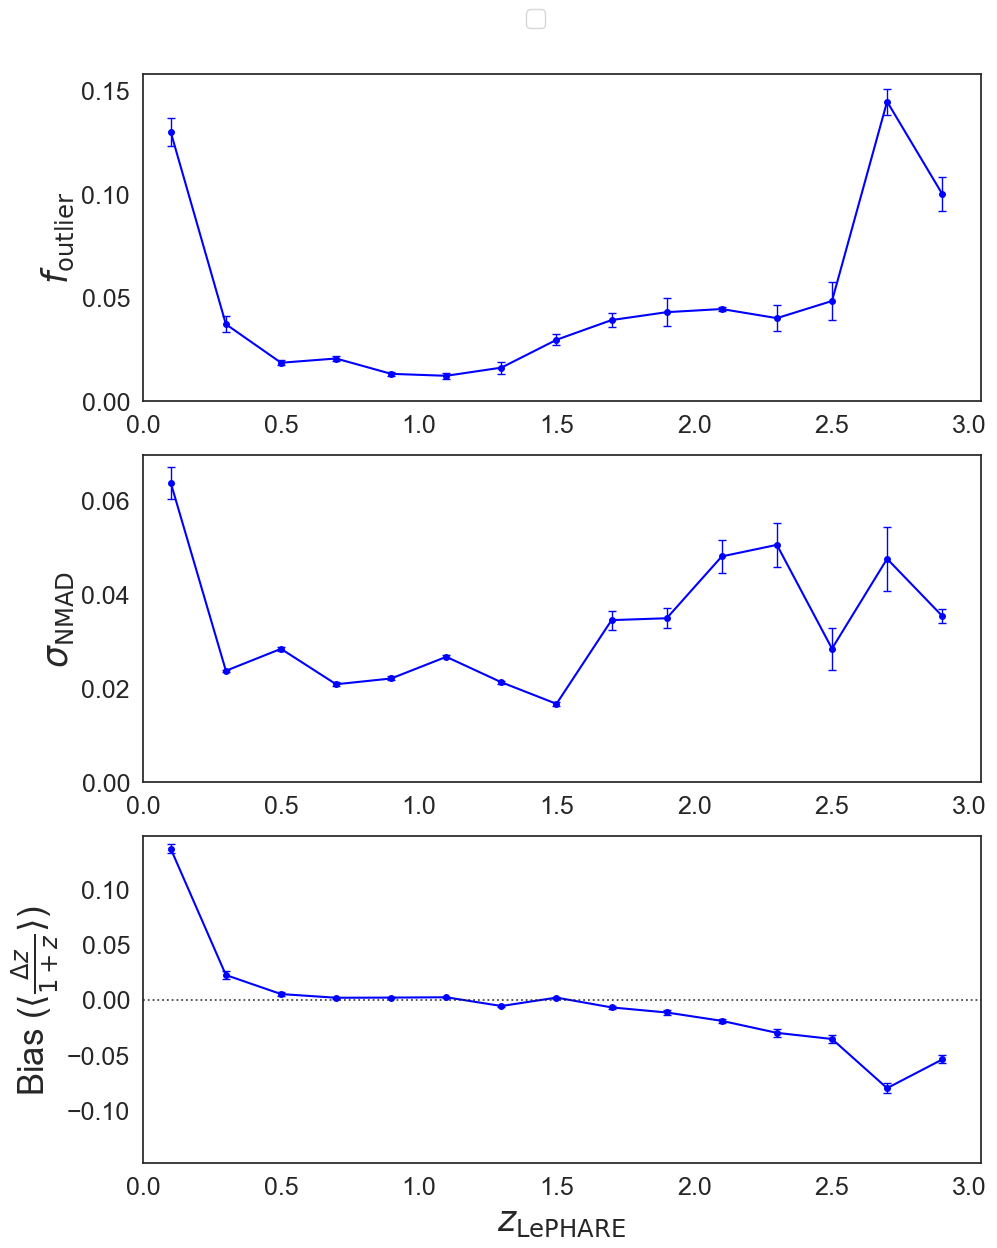

In [16]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(10,12))

    fout_ymax = 1.05*(np.max(size_binned_results['outliers_mean'])+np.max(size_binned_results['unc_size_outliers']))
    nmad_ymax = 1.05*(np.max(size_binned_results['nmads_mean'])+np.max(size_binned_results['unc_size_nmads']))
    bias_ymax = 1.05*(np.max(size_binned_results['biases_mean'])+np.max(size_binned_results['unc_size_biases']))
    bin_centers = size_binned_results['bin_centers']
    bin_min = 0.0

    # OUTLIERS
    #axs[0].plot(bin_centers, umap_outliers, c='blue', ls='--', label='UMAP (LePHARE-trained)')
    #axs[0].scatter(bin_centers, umap_outliers, c='blue', s=20)
    metric='outliers'
    axs[0].errorbar(bin_centers, size_binned_results[metric+'_mean'], yerr=size_binned_results['unc_size_'+metric], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[0].plot(bin_centers, size_binned_results[metric+'_mean'], c='blue', ls='-')


    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_ylim(0,None)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    #axs[1].plot(bin_centers, umap_nmads, c='blue', ls='--')
    #axs[1].scatter(bin_centers, umap_nmads, c='blue', s=20)
    metric='nmads'
    axs[1].errorbar(bin_centers, size_binned_results[metric+'_mean'], yerr=size_binned_results['unc_size_'+metric], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[1].plot(bin_centers, size_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_ylim(0,None)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    #axs[2].plot(bin_centers, umap_biases, c='blue', ls='--')
    #axs[2].scatter(bin_centers, umap_biases, c='blue', s=20)
    metric='biases'
    axs[2].errorbar(bin_centers, size_binned_results[metric+'_mean'], yerr=size_binned_results['unc_size_'+metric], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[2].plot(bin_centers, size_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    axs[2].set_ylim(-bias_ymax,bias_ymax)
    axs[2].set_xlim(bin_min,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### uncertainty due to sigma optimization

The parquet file we've loaded already contains SOM coordinates generated with our range of sigma values. Holding the size at (50,100) and the learning_rate at 0.8, we'll vary sigma over [0.85, 1.0, 1.15].

In [18]:
sigmas = [0.85, 1, 1.15]

sigma_b_sets = {str(sigma): [0] for sigma in sigmas}
sigma_b_results = {str(sigma): [0] for sigma in sigmas}

sigma_b_outliers_mean = []
sigma_b_nmads_mean = []
sigma_b_biases_mean = []

for sigma in sigmas:
    sigma_b_results[str(sigma)], sigma_b_sets[str(sigma)] = umapz2.crossvalidate_binned(folds=5, data=valid, nn=75, 
                                    map='SOM_75_150_s'+str(sigma)+'_lr0.8', tv='lp_photoz', dim=2, rematch=True)
    sigma_b_outliers_mean.append(sigma_b_results[str(sigma)]['outliers_mean'])
    sigma_b_nmads_mean.append(sigma_b_results[str(sigma)]['nmads_mean'])
    sigma_b_biases_mean.append(sigma_b_results[str(sigma)]['biases_mean'])

unc_sigma_outliers = (np.asarray(sigma_b_outliers_mean).max(axis=0) - np.asarray(sigma_b_outliers_mean).min(axis=0))/2
unc_sigma_nmads = (np.asarray(sigma_b_nmads_mean).max(axis=0) - np.asarray(sigma_b_nmads_mean).min(axis=0))/2
unc_sigma_biases = (np.asarray(sigma_b_biases_mean).max(axis=0) - np.asarray(sigma_b_biases_mean).min(axis=0))/2

In [19]:
sigma_binned_results = {
'bin_centers':sigma_b_results['1']['bin_centers'],
'outliers_mean':sigma_b_results['1']['outliers_mean'],
'nmads_mean':sigma_b_results['1']['nmads_mean'],
'biases_mean':sigma_b_results['1']['biases_mean'],
'unc_sigma_outliers':unc_sigma_outliers,
'unc_sigma_nmads':unc_sigma_nmads,
'unc_sigma_biases':unc_sigma_biases
}

### uncertainty due to learning_rate optimization

In [20]:
learning_rates = [0.68, 0.8, 0.92]

learning_rate_b_sets = {str(learning_rate): [0] for learning_rate in learning_rates}
learning_rate_b_results = {str(learning_rate): [0] for learning_rate in learning_rates}

outliers_b_mean = []
nmads_b_mean = []
biases_b_mean = []

for learning_rate in learning_rates:
    learning_rate_b_results[str(learning_rate)], learning_rate_b_sets[str(learning_rate)] = umapz2.crossvalidate_binned(folds=5, 
                                    data=valid, nn=75, map='SOM_75_150_s1_lr'+str(learning_rate), 
                                    tv='lp_photoz', dim=2, rematch=True)
    outliers_b_mean.append(learning_rate_b_results[str(learning_rate)]['outliers_mean'])
    nmads_b_mean.append(learning_rate_b_results[str(learning_rate)]['nmads_mean'])
    biases_b_mean.append(learning_rate_b_results[str(learning_rate)]['biases_mean'])

unc_learning_rate_outliers = (np.asarray(outliers_b_mean).max(axis=0) - np.asarray(outliers_b_mean).min(axis=0))/2
unc_learning_rate_nmads = (np.asarray(nmads_b_mean).max(axis=0) - np.asarray(nmads_b_mean).min(axis=0))/2
unc_learning_rate_biases = (np.asarray(biases_b_mean).max(axis=0) - np.asarray(biases_b_mean).min(axis=0))/2

In [21]:
learning_rate_binned_results = {
'bin_centers':learning_rate_b_results['0.8']['bin_centers'],
'outliers_mean':learning_rate_b_results['0.8']['outliers_mean'],
'nmads_mean':learning_rate_b_results['0.8']['nmads_mean'],
'biases_mean':learning_rate_b_results['0.8']['biases_mean'],
'unc_learning_rate_outliers':unc_learning_rate_outliers,
'unc_learning_rate_nmads':unc_learning_rate_nmads,
'unc_learning_rate_biases':unc_learning_rate_biases
}

### uncertainty due to different random seeds

In [22]:
#rs_data = pd.read_parquet('som_rs25_maps.parquet') # 'photo_rs25_maps.parquet' was made with n_neighbors=80
rs_data = pd.read_parquet('som_rs25_maps_manhattan_260509.parquet')

In [23]:
rs_spec = pd.merge(rs_data.copy()[rs_data['ID'].isin(spec95['ID'])], spec95[['ID', 'specz']], left_on='ID', right_on='ID', how='left')
rs_test = rs_data.copy()[rs_data['ID'].isin(splits['test_spec']['ID'])]
rs_test_lp = rs_data.copy()[rs_data['ID'].isin(splits['test_lp']['ID'])]
rs_train_lp = rs_data.copy()[rs_data['ID'].isin(splits['train_lp']['ID'])]

In [24]:
n_embeddings=25
outliers_rs = []
nmads_rs = []
biases_rs = []

outliers_rs_lp = []
nmads_rs_lp = []
biases_rs_lp = []

# interpolate
for i in range(n_embeddings+1):
    rs_test['TEST_Zrs'+str(i)] = umapz2.som_rematch(df1=rs_spec, df2=rs_test, map='SOMrs'+str(i), zlabel='specz', nn=75).copy()['TEST_Z']
    outliers_rs.append(umapz2.f_outlier(i_vals=rs_test['TEST_Zrs'+str(i)], t_vals=rs_test['lp_photoz'], missing=0, threshold=0.15))
    nmads_rs.append(umapz2.calc_nmad(i_vals=rs_test['TEST_Zrs'+str(i)], t_vals=rs_test['lp_photoz']))
    biases_rs.append(umapz2.calc_bias(i_vals=rs_test['TEST_Zrs'+str(i)], t_vals=rs_test['lp_photoz']))

    rs_test_lp['TEST_Zrs'+str(i)] = umapz2.som_rematch(df1=rs_train_lp, df2=rs_test_lp, map='SOMrs'+str(i), zlabel='lp_photoz', nn=75).copy()['TEST_Z']
    outliers_rs_lp.append(umapz2.f_outlier(i_vals=rs_test_lp['TEST_Zrs'+str(i)], t_vals=rs_test_lp['lp_photoz'], missing=0, threshold=0.15))
    nmads_rs_lp.append(umapz2.calc_nmad(i_vals=rs_test_lp['TEST_Zrs'+str(i)], t_vals=rs_test_lp['lp_photoz']))
    biases_rs_lp.append(umapz2.calc_bias(i_vals=rs_test_lp['TEST_Zrs'+str(i)], t_vals=rs_test_lp['lp_photoz']))

In [25]:
# convert to arrays: shape = (n_realizations, n_bins)
outliers_rs = np.asarray(outliers_rs)
nmads_rs = np.asarray(nmads_rs)
biases_rs = np.asarray(biases_rs)

outliers_rs_lp = np.asarray(outliers_rs_lp)
nmads_rs_lp = np.asarray(nmads_rs_lp)
biases_rs_lp = np.asarray(biases_rs_lp)

rs_results = {
    "outliers_mean": outliers_rs.mean(axis=0),
    "outliers_std": outliers_rs.std(axis=0),

    "nmads_mean": nmads_rs.mean(axis=0),
    "nmads_std": nmads_rs.std(axis=0),

    "biases_mean": biases_rs.mean(axis=0),
    "biases_std": biases_rs.std(axis=0),

    "outliers_mean_lp": outliers_rs_lp.mean(axis=0),
    "outliers_std_lp": outliers_rs_lp.std(axis=0),

    "nmads_mean_lp": nmads_rs_lp.mean(axis=0),
    "nmads_std_lp": nmads_rs_lp.std(axis=0),

    "biases_mean_lp": biases_rs_lp.mean(axis=0),
    "biases_std_lp": biases_rs_lp.std(axis=0)
}

In [26]:
metrics = ['outliers', 'nmads', 'biases']
for metric in metrics:
    print(metric+' mean:', rs_results[metric+'_mean'])
    print(metric+' stdev:', rs_results[metric+'_std'])

outliers mean: 0.04303453070128127
outliers stdev: 0.0006192814233915629
nmads mean: 0.027563366820037596
nmads stdev: 0.0001294856955638557
biases mean: 0.008847189917113526
biases stdev: 0.000433638117985298


In [27]:
testcats_rs = []
testcats_rs_lp = []
for i in range(1,n_embeddings+1): 
    testcat_i = rs_test.copy()[['lp_photoz', 'TEST_Zrs'+str(i)]]
    testcat_i['TEST_Z'] = testcat_i['TEST_Zrs'+str(i)]
    testcats_rs.append(testcat_i.copy())

    testcat_i_lp = rs_test_lp.copy()[['lp_photoz', 'TEST_Zrs'+str(i)]]
    testcat_i_lp['TEST_Z'] = testcat_i_lp['TEST_Zrs'+str(i)]
    testcats_rs_lp.append(testcat_i_lp.copy())

rs_binned_results = umapz2.binned_stats_ensemble(fullcats=testcats_rs, testcats=testcats_rs, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                            bin_min=0.0, bin_max=3.0, bin_size=0.2)
rs_binned_results_lp = umapz2.binned_stats_ensemble(fullcats=testcats_rs_lp, testcats=testcats_rs_lp, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                            bin_min=0.0, bin_max=3.0, bin_size=0.2)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


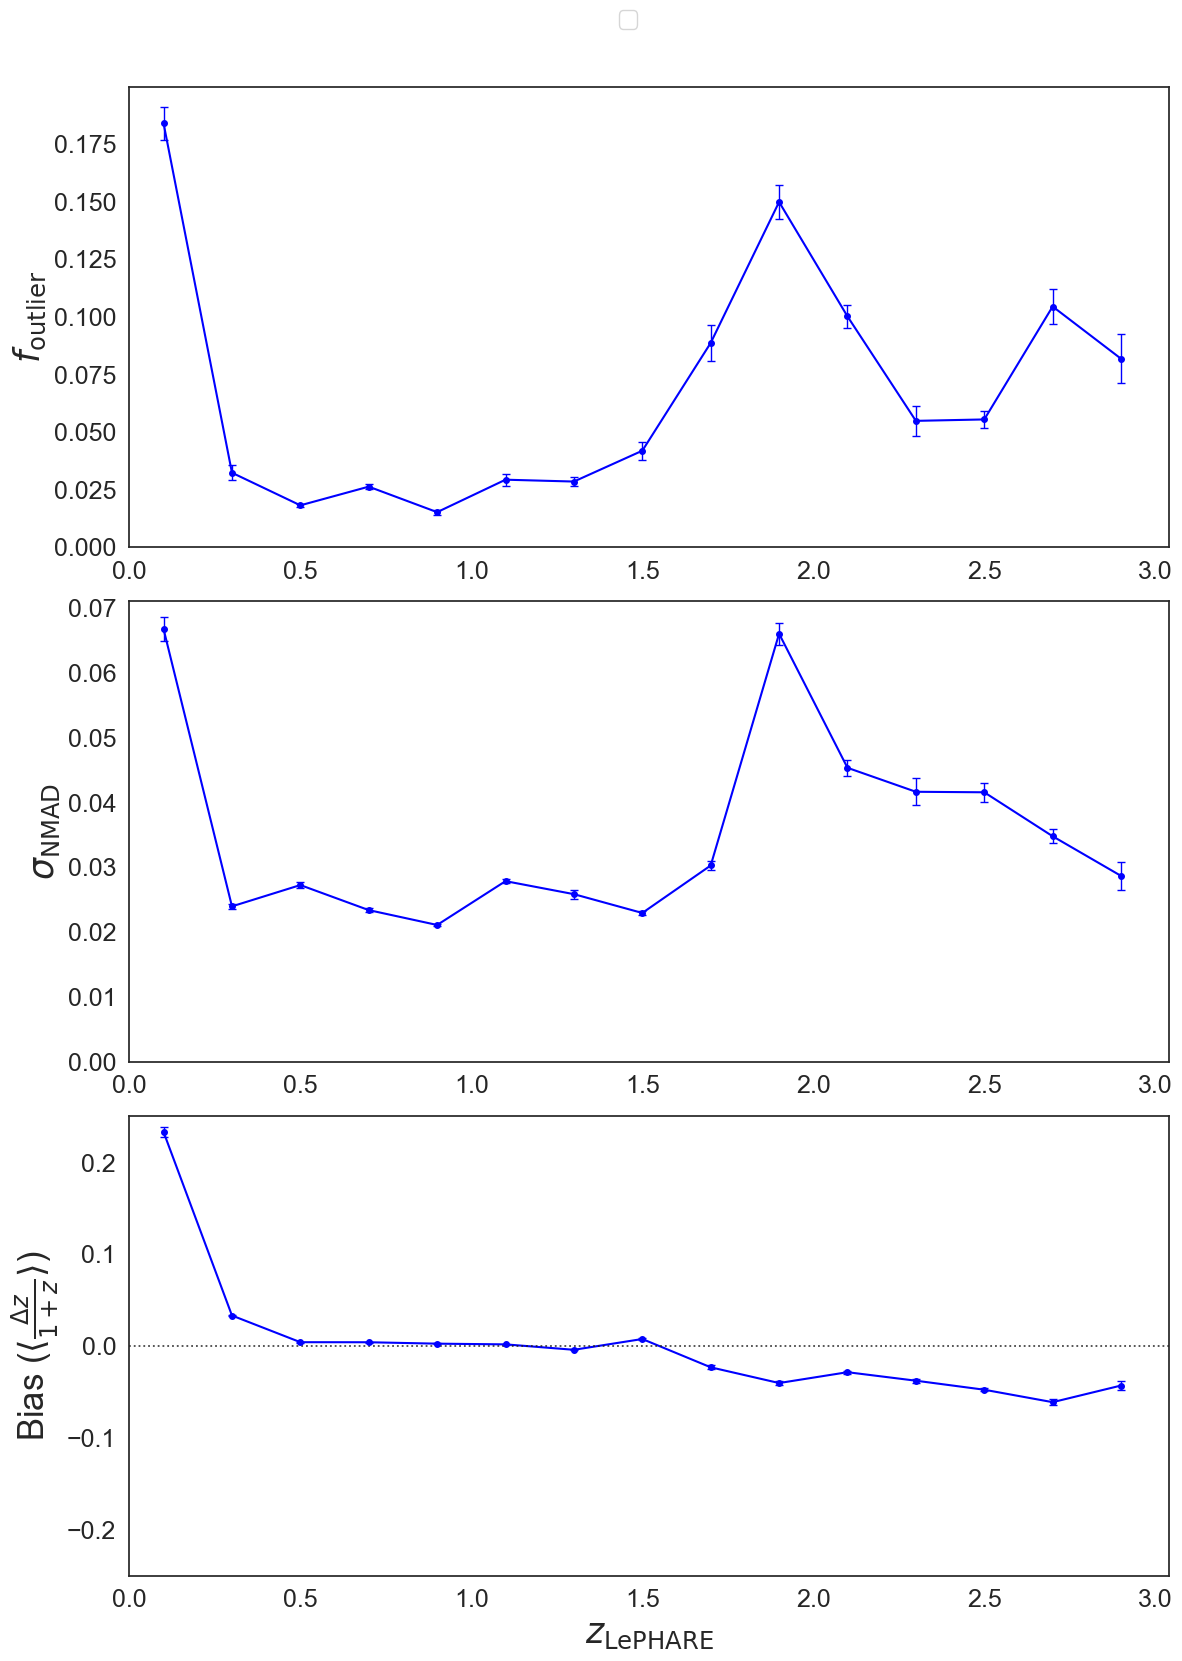

In [28]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(12,16))

    fout_ymax = 1.05*(np.max(rs_binned_results['outliers_mean'])+np.max(rs_binned_results['outliers_std']))
    nmad_ymax = 1.05*(np.max(rs_binned_results['nmads_mean'])+np.max(rs_binned_results['nmads_std']))
    bias_ymax = 1.05*(np.max(rs_binned_results['biases_mean'])+np.max(rs_binned_results['biases_std']))
    bin_centers = rs_binned_results['bin_centers']
    bin_min = 0.0

    # OUTLIERS
    #axs[0].plot(bin_centers, umap_outliers, c='blue', ls='--', label='UMAP (LePHARE-trained)')
    #axs[0].scatter(bin_centers, umap_outliers, c='blue', s=20)
    metric='outliers'
    axs[0].errorbar(bin_centers, rs_binned_results[metric+'_mean'], yerr=rs_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[0].plot(bin_centers, rs_binned_results[metric+'_mean'], c='blue', ls='-')


    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_ylim(0,None)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    #axs[1].plot(bin_centers, umap_nmads, c='blue', ls='--')
    #axs[1].scatter(bin_centers, umap_nmads, c='blue', s=20)
    metric='nmads'
    axs[1].errorbar(bin_centers, rs_binned_results[metric+'_mean'], yerr=rs_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[1].plot(bin_centers, rs_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_ylim(0,None)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    #axs[2].plot(bin_centers, umap_biases, c='blue', ls='--')
    #axs[2].scatter(bin_centers, umap_biases, c='blue', s=20)
    metric='biases'
    axs[2].errorbar(bin_centers, rs_binned_results[metric+'_mean'], yerr=rs_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[2].plot(bin_centers, rs_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    axs[2].set_ylim(-bias_ymax,bias_ymax)
    axs[2].set_xlim(bin_min,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### uncertainty due to finite test set

To quantify the uncertainty due to the finite test set, we take 10-25 bootstrap samples of the test set (spec-z-trained case) and perform the main redshift-binned interpolation test with fixed k, n_neighbors, and random seed. The standard deviation of the performance metrics in each bin will be taken as the uncertainty due to finite test size.

Since the random seed test we just performed used fixed n_neighbors and fixed k, if we pick a particular seed from which to use the interpolated redshifts, we can use this sample for our bootstrap performance statistics calculations.

Let's go with 3.

In [29]:
rs_test[['TEST_Zrs3']]

,TEST_Zrs3
7,0.678300
39,0.478650
40,1.573075
46,1.022980
76,1.223925
...,...
746897,0.395715
746898,2.363300
746904,2.413000
746908,0.811350


In [30]:
n_boots=25
rs=3
outliers_boots = []
nmads_boots = []
stdevs_boots = []
biases_boots = []
testcats_boots = []
outliers_boots_lp = []
nmads_boots_lp = []
stdevs_boots_lp = []
biases_boots_lp = []
testcats_boots_lp = []

for i in range(1, n_boots+1):
    boot_i = rs_test.sample(n=len(rs_test), replace=True, random_state=i)
    testcats_boots.append(boot_i.copy())
    outliers_boots.append(umapz2.f_outlier(i_vals=boot_i['TEST_Zrs'+str(rs)], t_vals=boot_i['lp_photoz'], 
                                           missing=0, threshold=0.15))
    nmads_boots.append(umapz2.calc_nmad(i_vals=boot_i['TEST_Zrs'+str(rs)], t_vals=boot_i['lp_photoz']))
    stdevs_boots.append(umapz2.calc_stdev(i_vals=boot_i['TEST_Zrs'+str(rs)], t_vals=boot_i['lp_photoz']))
    biases_boots.append(umapz2.calc_bias(i_vals=boot_i['TEST_Zrs'+str(rs)], t_vals=boot_i['lp_photoz']))

    boot_i_lp = rs_test_lp.sample(n=len(rs_test_lp), replace=True, random_state=i)
    testcats_boots_lp.append(boot_i_lp.copy())
    outliers_boots_lp.append(umapz2.f_outlier(i_vals=boot_i_lp['TEST_Zrs'+str(rs)], t_vals=boot_i_lp['lp_photoz'], 
                                           missing=0, threshold=0.15))
    nmads_boots_lp.append(umapz2.calc_nmad(i_vals=boot_i_lp['TEST_Zrs'+str(rs)], t_vals=boot_i_lp['lp_photoz']))
    stdevs_boots_lp.append(umapz2.calc_stdev(i_vals=boot_i_lp['TEST_Zrs'+str(rs)], t_vals=boot_i_lp['lp_photoz']))
    biases_boots_lp.append(umapz2.calc_bias(i_vals=boot_i_lp['TEST_Zrs'+str(rs)], t_vals=boot_i_lp['lp_photoz']))

In [31]:
# convert to arrays: shape = (n_realizations, n_bins)
outliers_boots = np.asarray(outliers_boots)
nmads_boots = np.asarray(nmads_boots)
stdevs_boots = np.asarray(stdevs_boots)
biases_boots = np.asarray(biases_boots)

outliers_boots_lp = np.asarray(outliers_boots_lp)
nmads_boots_lp = np.asarray(nmads_boots_lp)
stdevs_boots_lp = np.asarray(stdevs_boots_lp)
biases_boots_lp = np.asarray(biases_boots_lp)

boots_results = {
    "outliers_mean": outliers_boots.mean(axis=0),
    "outliers_std": outliers_boots.std(axis=0),

    "nmads_mean": nmads_boots.mean(axis=0),
    "nmads_std": nmads_boots.std(axis=0),

    "stdevs_mean": stdevs_boots.mean(axis=0),
    "stdevs_std": stdevs_boots.std(axis=0),

    "biases_mean": biases_boots.mean(axis=0),
    "biases_std": biases_boots.std(axis=0),

    "outliers_mean_lp": outliers_boots_lp.mean(axis=0),
    "outliers_std_lp": outliers_boots_lp.std(axis=0),

    "nmads_mean_lp": nmads_boots_lp.mean(axis=0),
    "nmads_std_lp": nmads_boots_lp.std(axis=0),

    "stdevs_mean_lp": stdevs_boots_lp.mean(axis=0),
    "stdevs_std_lp": stdevs_boots_lp.std(axis=0),

    "biases_mean_lp": biases_boots_lp.mean(axis=0),
    "biases_std_lp": biases_boots_lp.std(axis=0)
}

In [32]:
metrics = ['outliers', 'nmads', 'stdevs', 'biases']
for metric in metrics:
    print(metric+' mean:', np.round(boots_results[metric+'_mean'], 6))
    print(metric+' stdev:', np.round(boots_results[metric+'_std'], 6))

outliers mean: 0.043401
outliers stdev: 0.000661
nmads mean: 0.0277
nmads stdev: 0.000113
stdevs mean: 0.180692
stdevs stdev: 0.003851
biases mean: 0.009219
biases stdev: 0.000667


In [33]:
boots_binned_results = umapz2.binned_stats_ensemble(fullcats=testcats_boots, testcats=testcats_boots, iv='TEST_Zrs'+str(rs), tv='lp_photoz', bin_var='lp_photoz',
                            bin_min=0.0, bin_max=3.0, bin_size=0.2)

boots_binned_results_lp = umapz2.binned_stats_ensemble(fullcats=testcats_boots_lp, testcats=testcats_boots_lp, iv='TEST_Zrs'+str(rs), tv='lp_photoz', bin_var='lp_photoz',
                            bin_min=0.0, bin_max=3.0, bin_size=0.2)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


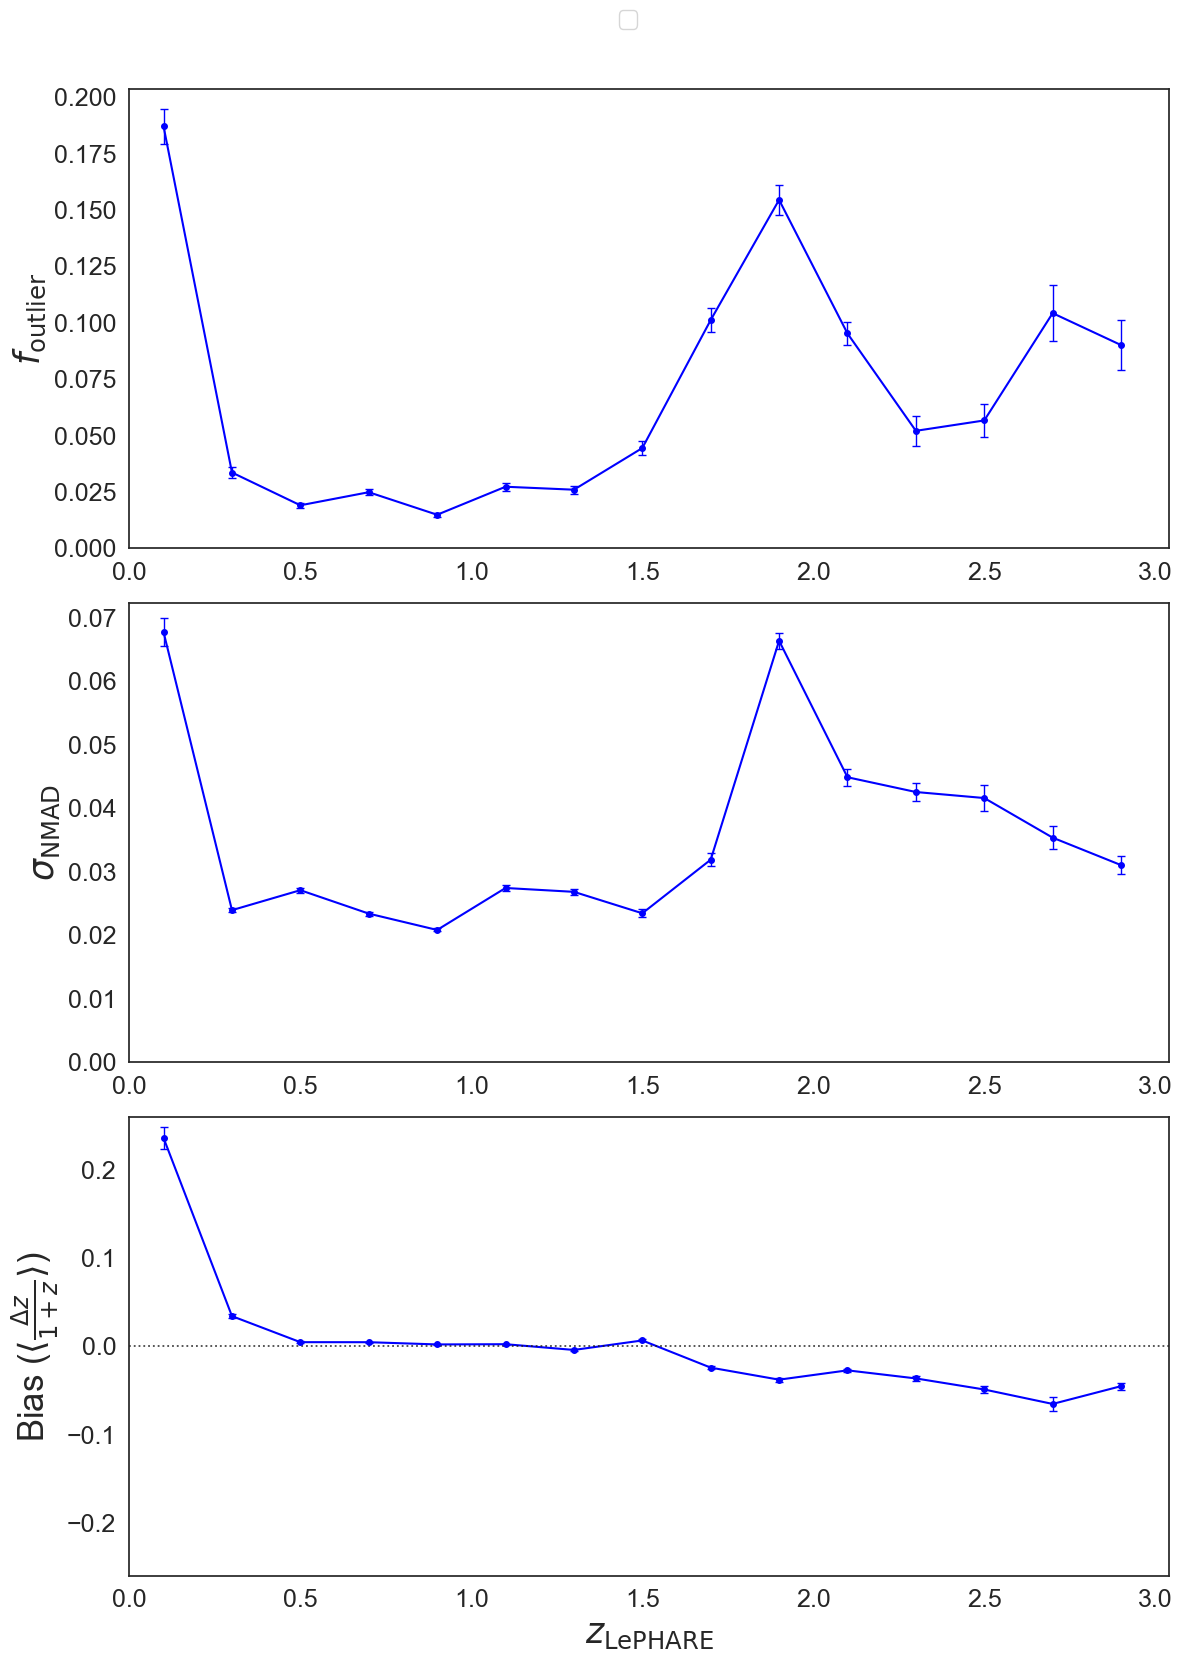

In [34]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(12,16))

    fout_ymax = 1.05*(np.max(boots_binned_results['outliers_mean'])+np.max(boots_binned_results['outliers_std']))
    nmad_ymax = 1.05*(np.max(boots_binned_results['nmads_mean'])+np.max(boots_binned_results['nmads_std']))
    bias_ymax = 1.05*(np.max(boots_binned_results['biases_mean'])+np.max(boots_binned_results['biases_std']))
    bin_centers = boots_binned_results['bin_centers']
    bin_min = 0.0

    # OUTLIERS
    #axs[0].plot(bin_centers, umap_outliers, c='blue', ls='--', label='UMAP (LePHARE-trained)')
    #axs[0].scatter(bin_centers, umap_outliers, c='blue', s=20)
    metric='outliers'
    axs[0].errorbar(bin_centers, boots_binned_results[metric+'_mean'], yerr=boots_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[0].plot(bin_centers, boots_binned_results[metric+'_mean'], c='blue', ls='-')


    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_ylim(0,None)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    #axs[1].plot(bin_centers, umap_nmads, c='blue', ls='--')
    #axs[1].scatter(bin_centers, umap_nmads, c='blue', s=20)
    metric='nmads'
    axs[1].errorbar(bin_centers, boots_binned_results[metric+'_mean'], yerr=boots_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[1].plot(bin_centers, boots_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_ylim(0,None)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    #axs[2].plot(bin_centers, umap_biases, c='blue', ls='--')
    #axs[2].scatter(bin_centers, umap_biases, c='blue', s=20)
    metric='biases'
    axs[2].errorbar(bin_centers, boots_binned_results[metric+'_mean'], yerr=boots_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[2].plot(bin_centers, boots_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    axs[2].set_ylim(-bias_ymax,bias_ymax)
    axs[2].set_xlim(bin_min,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### spec-z-trained sandplot

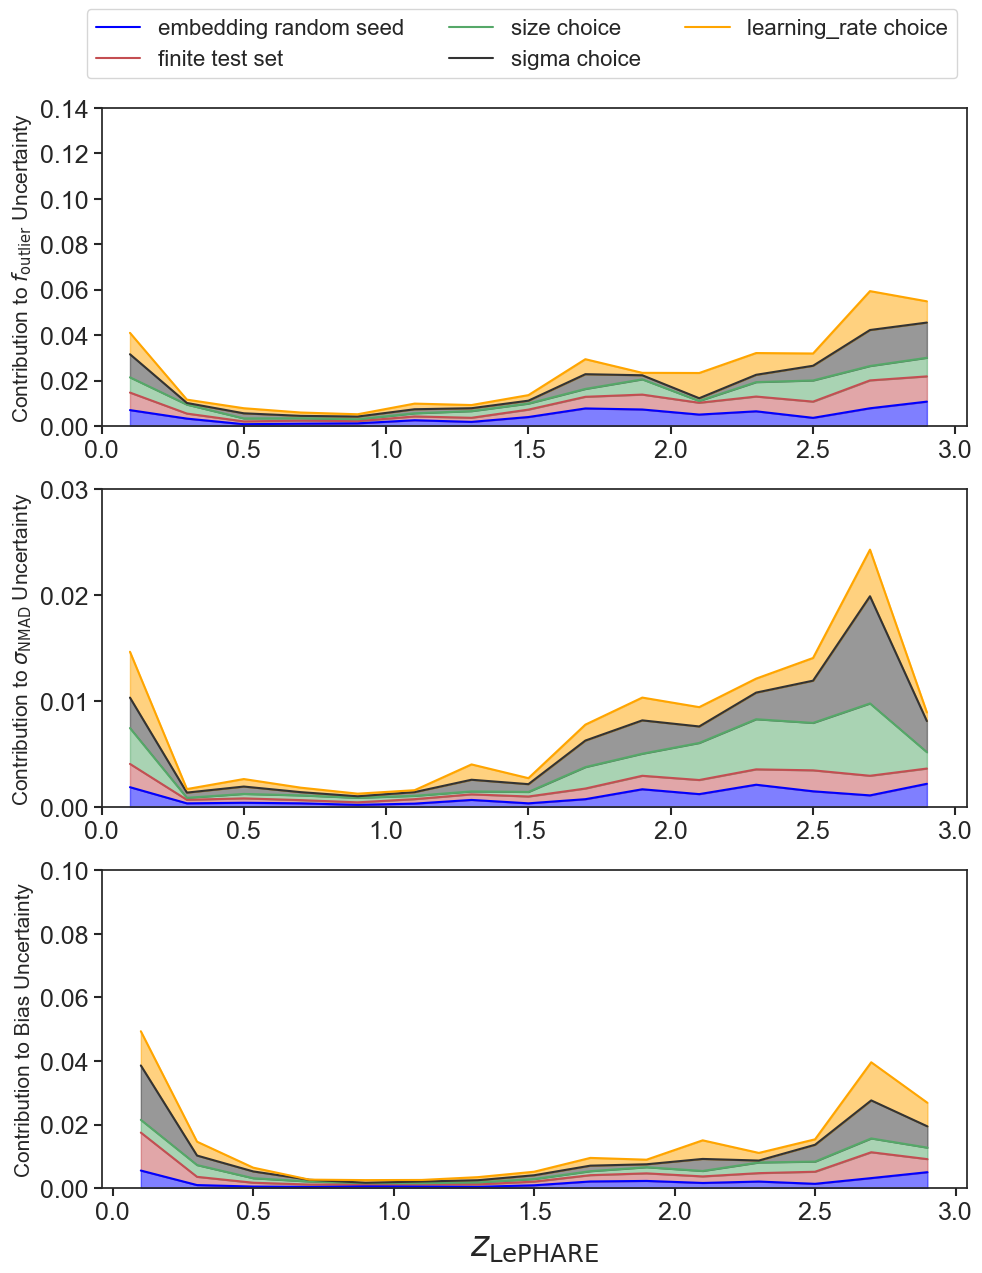

In [75]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(10,12))
    c1, c2, c3, c4, c5 = 'blue', 'r', 'g', '0.2', 'orange'
    l1 = 'embedding random seed'
    l4 = 'sigma choice'
    l3 = 'size choice'
    l2 = 'finite test set'
    l5 = 'learning_rate choice'
    alpha=0.5

    #ticks
    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=18, length=6, width=1.5, 
                        bottom=True,top=False,left=True, right=False,
                        direction='out')
        #ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    axs[0].yaxis.set_major_locator(MultipleLocator(0.02))
    axs[1].yaxis.set_major_locator(MultipleLocator(0.01))
    axs[2].yaxis.set_major_locator(MultipleLocator(0.02))

    # OUTLIERS
    metric='outliers'
    unc1, unc2, unc3, unc4, unc5 = [rs_binned_results[metric+"_std"], boots_binned_results[metric+'_std'], 
                    size_binned_results['unc_size_'+metric], 
                    sigma_binned_results['unc_sigma_'+metric], learning_rate_binned_results['unc_learning_rate_'+metric]]
    axs[0].plot(bin_centers, unc1, c=c1, ls='-', label=l1)
    axs[0].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[0].plot(bin_centers, unc2+unc1, c=c2, ls='-', label=l2)
    axs[0].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[0].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-', label=l3)
    axs[0].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[0].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-', label=l4)
    axs[0].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[0].plot(bin_centers, unc5+unc4+unc3+unc2+unc1, c=c5, ls='-', label=l5)
    axs[0].fill_between(bin_centers, unc5+unc4+unc3+unc2+unc1,y2=unc4+unc3+unc2+unc1, alpha=alpha, color=c5)
    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel('Contribution to '+r'$f_\mathrm{outlier}$'+' Uncertainty', fontsize=15)
    axs[0].set_ylim(0, 0.14)
    # NMADS
    metric='nmads'
    unc1, unc2, unc3, unc4, unc5 = [rs_binned_results[metric+"_std"], boots_binned_results[metric+'_std'],
                    size_binned_results['unc_size_'+metric], 
                    sigma_binned_results['unc_sigma_'+metric], learning_rate_binned_results['unc_learning_rate_'+metric]]    
    axs[1].plot(bin_centers, unc1, c=c1, ls='-')
    axs[1].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[1].plot(bin_centers, unc2+unc1, c=c2, ls='-')
    axs[1].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[1].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-')
    axs[1].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[1].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-')
    axs[1].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[1].plot(bin_centers, unc5+unc4+unc3+unc2+unc1, c=c5, ls='-')
    axs[1].fill_between(bin_centers, unc5+unc4+unc3+unc2+unc1,y2=unc4+unc3+unc2+unc1, alpha=alpha, color=c5)
    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel('Contribution to '+r'$\sigma_\mathrm{NMAD}$'+' Uncertainty', fontsize=15)
    axs[1].set_ylim(0, 0.03)
    # BIASES
    metric='biases'
    unc1, unc2, unc3, unc4, unc5 = [rs_binned_results[metric+"_std"], boots_binned_results[metric+'_std'], 
                    size_binned_results['unc_size_'+metric], 
                    sigma_binned_results['unc_sigma_'+metric], learning_rate_binned_results['unc_learning_rate_'+metric]]    
    axs[2].plot(bin_centers, unc1, c=c1, ls='-')
    axs[2].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[2].plot(bin_centers, unc2+unc1, c=c2, ls='-')
    axs[2].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[2].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-')
    axs[2].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[2].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-')
    axs[2].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[2].plot(bin_centers, unc5+unc4+unc3+unc2+unc1, c=c5, ls='-')
    axs[2].fill_between(bin_centers, unc5+unc4+unc3+unc2+unc1,y2=unc4+unc3+unc2+unc1, alpha=alpha, color=c5)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Contribution to Bias Uncertainty', fontsize=15)
    axs[2].set_ylim(0, 0.1)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=3, borderaxespad=0., fontsize=16)
    fig.tight_layout()
    #fig.suptitle('Uncertainties Related to UMAP Embedding and Optimization', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### LePHARE-trained sandplot

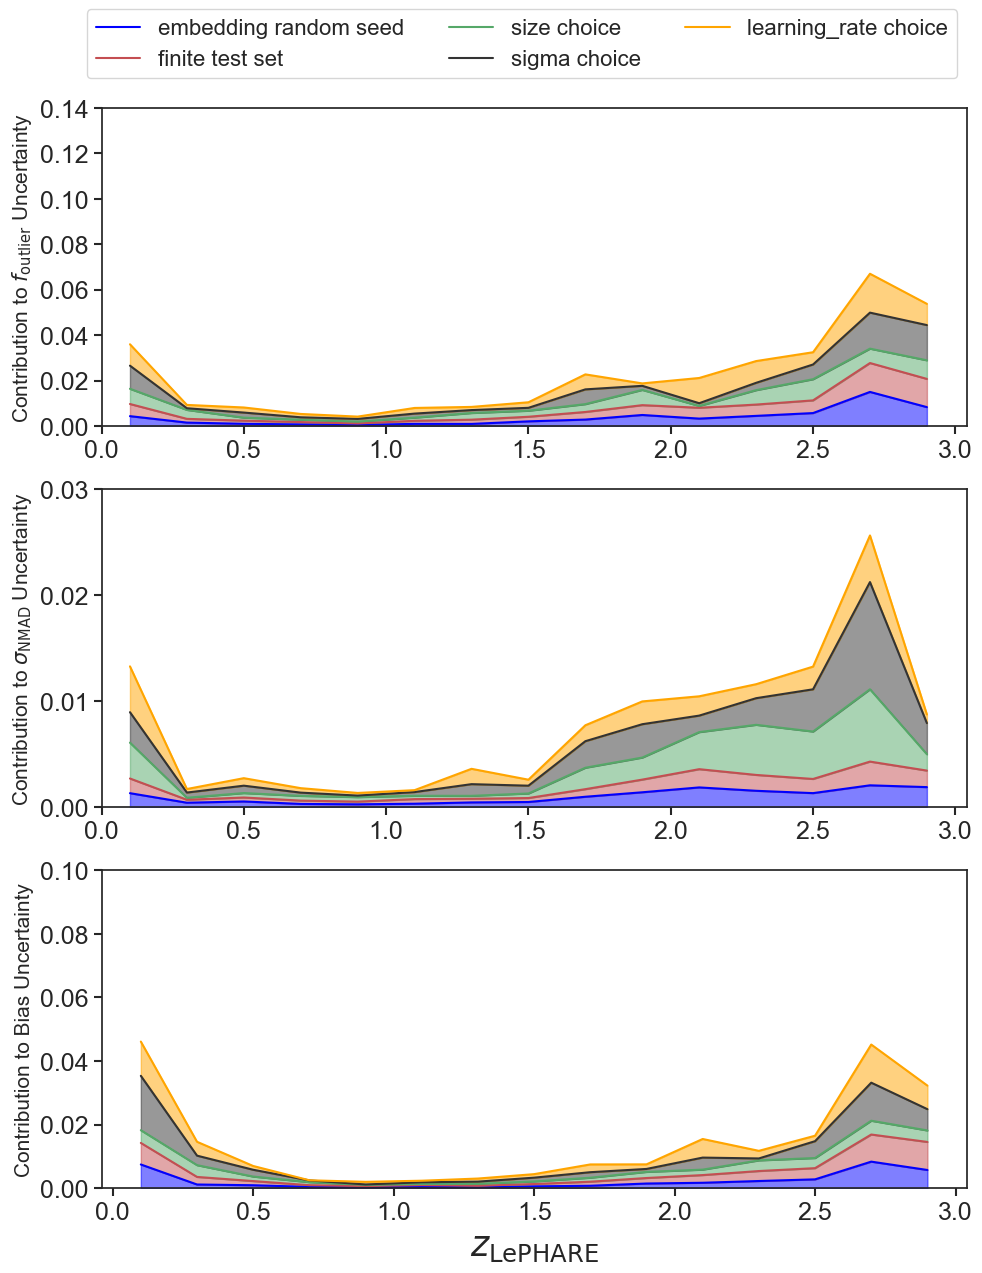

In [76]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(10,12))
    c1, c2, c3, c4, c5 = 'blue', 'r', 'g', '0.2', 'orange'
    l1 = 'embedding random seed'
    l4 = 'sigma choice'
    l3 = 'size choice'
    l2 = 'finite test set'
    l5 = 'learning_rate choice'
    alpha=0.5

    #ticks
    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=18, length=6, width=1.5, 
                        bottom=True,top=False,left=True, right=False,
                        direction='out')
        #ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    axs[0].yaxis.set_major_locator(MultipleLocator(0.02))
    axs[1].yaxis.set_major_locator(MultipleLocator(0.01))
    axs[2].yaxis.set_major_locator(MultipleLocator(0.02))

    # OUTLIERS
    metric='outliers'
    unc1, unc2, unc3, unc4, unc5 = [rs_binned_results_lp[metric+'_std'], boots_binned_results_lp[metric+'_std'], 
                    size_binned_results['unc_size_'+metric], 
                    sigma_binned_results['unc_sigma_'+metric], learning_rate_binned_results['unc_learning_rate_'+metric]]
    axs[0].plot(bin_centers, unc1, c=c1, ls='-', label=l1)
    axs[0].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[0].plot(bin_centers, unc2+unc1, c=c2, ls='-', label=l2)
    axs[0].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[0].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-', label=l3)
    axs[0].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[0].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-', label=l4)
    axs[0].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[0].plot(bin_centers, unc5+unc4+unc3+unc2+unc1, c=c5, ls='-', label=l5)
    axs[0].fill_between(bin_centers, unc5+unc4+unc3+unc2+unc1,y2=unc4+unc3+unc2+unc1, alpha=alpha, color=c5)
    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel('Contribution to '+r'$f_\mathrm{outlier}$'+' Uncertainty', fontsize=15)
    axs[0].set_ylim(0, 0.14)
    # NMADS
    metric='nmads'
    unc1, unc2, unc3, unc4, unc5 = [rs_binned_results_lp[metric+'_std'], boots_binned_results_lp[metric+'_std'], 
                    size_binned_results['unc_size_'+metric], 
                    sigma_binned_results['unc_sigma_'+metric], learning_rate_binned_results['unc_learning_rate_'+metric]]    
    axs[1].plot(bin_centers, unc1, c=c1, ls='-')
    axs[1].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[1].plot(bin_centers, unc2+unc1, c=c2, ls='-')
    axs[1].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[1].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-')
    axs[1].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[1].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-')
    axs[1].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[1].plot(bin_centers, unc5+unc4+unc3+unc2+unc1, c=c5, ls='-')
    axs[1].fill_between(bin_centers, unc5+unc4+unc3+unc2+unc1,y2=unc4+unc3+unc2+unc1, alpha=alpha, color=c5)
    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel('Contribution to '+r'$\sigma_\mathrm{NMAD}$'+' Uncertainty', fontsize=15)
    axs[1].set_ylim(0, 0.03)
    # BIASES
    metric='biases'
    unc1, unc2, unc3, unc4, unc5 = [rs_binned_results_lp[metric+'_std'], boots_binned_results_lp[metric+'_std'],  
                    size_binned_results['unc_size_'+metric], 
                    sigma_binned_results['unc_sigma_'+metric], learning_rate_binned_results['unc_learning_rate_'+metric]]    
    axs[2].plot(bin_centers, unc1, c=c1, ls='-')
    axs[2].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[2].plot(bin_centers, unc2+unc1, c=c2, ls='-')
    axs[2].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[2].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-')
    axs[2].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[2].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-')
    axs[2].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[2].plot(bin_centers, unc5+unc4+unc3+unc2+unc1, c=c5, ls='-')
    axs[2].fill_between(bin_centers, unc5+unc4+unc3+unc2+unc1,y2=unc4+unc3+unc2+unc1, alpha=alpha, color=c5)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Contribution to Bias Uncertainty', fontsize=15)
    axs[2].set_ylim(0, 0.1)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=3, borderaxespad=0., fontsize=16)
    fig.tight_layout()
    #fig.suptitle('Uncertainties Related to UMAP Embedding and Optimization', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### Redshift-Binned Performance w/ Error Bars

Now we have quantified the uncertainties associated with our SOM-z implementation, and can add error bars to our plot of photo-z performance metrics vs redshift. For this, we will add the uncertainty sources in quadrature.

In [37]:
# LePHARE-tttttt
metric='outliers'
unc1_lp, unc2_lp, unc3_lp, unc4_lp, unc5_lp = [size_binned_results['unc_size_'+metric], 
    sigma_binned_results['unc_sigma_'+metric], 
    learning_rate_binned_results['unc_learning_rate_'+metric], rs_binned_results_lp[metric+'_std'],
    boots_binned_results_lp[metric+'_std']]
som_outlier_uncs_lp = np.sqrt(unc1_lp**2 + unc2_lp**2 + unc3_lp**2 + unc4_lp**2 + unc5_lp**2)
metric='nmads'
unc1_lp, unc2_lp, unc3_lp, unc4_lp, unc5_lp = [size_binned_results['unc_size_'+metric], 
    sigma_binned_results['unc_sigma_'+metric], 
    learning_rate_binned_results['unc_learning_rate_'+metric], rs_binned_results_lp[metric+'_std'],
    boots_binned_results_lp[metric+'_std']]
som_nmad_uncs_lp = np.sqrt(unc1_lp**2 + unc2_lp**2 + unc3_lp**2 + unc4_lp**2 + unc5_lp**2)
metric='biases'
unc1_lp, unc2_lp, unc3_lp, unc4_lp, unc5_lp = [size_binned_results['unc_size_'+metric], 
    sigma_binned_results['unc_sigma_'+metric], 
    learning_rate_binned_results['unc_learning_rate_'+metric], rs_binned_results_lp[metric+'_std'],
    boots_binned_results_lp[metric+'_std']]
som_bias_uncs_lp = np.sqrt(unc1_lp**2 + unc2_lp**2 + unc3_lp**2 + unc4_lp**2 + unc5_lp**2)

# spec-z-trained case
metric='outliers'
unc1, unc2, unc3, unc4, unc5 = [size_binned_results['unc_size_'+metric], 
    sigma_binned_results['unc_sigma_'+metric], 
    learning_rate_binned_results['unc_learning_rate_'+metric], rs_binned_results[metric+'_std'],
    boots_binned_results[metric+'_std']]
som_outlier_uncs = np.sqrt(unc1**2 + unc2**2 + unc3**2 + unc4**2 + unc5**2)
metric='nmads'
unc1, unc2, unc3, unc4, unc5 = [size_binned_results['unc_size_'+metric], 
    sigma_binned_results['unc_sigma_'+metric], 
    learning_rate_binned_results['unc_learning_rate_'+metric], rs_binned_results[metric+'_std'],
    boots_binned_results[metric+'_std']]
som_nmad_uncs = np.sqrt(unc1**2 + unc2**2 + unc3**2 + unc4**2 + unc5**2)
metric='biases'
unc1, unc2, unc3, unc4, unc5 = [size_binned_results['unc_size_'+metric], 
    sigma_binned_results['unc_sigma_'+metric], 
    learning_rate_binned_results['unc_learning_rate_'+metric], rs_binned_results[metric+'_std'],
    boots_binned_results[metric+'_std']]
som_bias_uncs = np.sqrt(unc1**2 + unc2**2 + unc3**2 + unc4**2 + unc5**2)

In [71]:
### write out individual uncertainty sources, in redshift bins
somrm_binned = {
'specz_trained':{
    'f_outlier':{
        'mean':rs_binned_results['outliers_mean'],
        'unc_size':size_binned_results['unc_size_outliers'],
        'unc_sigma':sigma_binned_results['unc_sigma_outliers'],
        'unc_learning_rate':learning_rate_binned_results['unc_learning_rate_outliers'],
        'unc_rs':rs_binned_results['outliers_std'],
        'unc_boots':boots_binned_results['outliers_std']
    },
    'nmad':{
        'mean':rs_binned_results['nmads_mean'],
        'unc_size':size_binned_results['unc_size_nmads'],
        'unc_sigma':sigma_binned_results['unc_sigma_nmads'],
        'unc_learning_rate':learning_rate_binned_results['unc_learning_rate_nmads'],
        'unc_rs':rs_binned_results['nmads_std'],
        'unc_boots':boots_binned_results['nmads_std']       
    },
    'bias':{
        'mean':rs_binned_results['biases_mean'],
        'unc_size':size_binned_results['unc_size_biases'],
        'unc_sigma':sigma_binned_results['unc_sigma_biases'],
        'unc_learning_rate':learning_rate_binned_results['unc_learning_rate_biases'],
        'unc_rs':rs_binned_results['biases_std'],
        'unc_boots':boots_binned_results['biases_std']
    },
    'bin_centers':rs_binned_results['bin_centers']
},
'LePHARE_trained':{
    'f_outlier':{
        'mean':rs_binned_results_lp['outliers_mean'],
        'unc_size':size_binned_results['unc_size_outliers'],
        'unc_sigma':sigma_binned_results['unc_sigma_outliers'],
        'unc_learning_rate':learning_rate_binned_results['unc_learning_rate_outliers'],
        'unc_rs':rs_binned_results_lp['outliers_std'],
        'unc_boots':boots_binned_results_lp['outliers_std']
    },
    'nmad':{
        'mean':rs_binned_results_lp['nmads_mean'],
        'unc_size':size_binned_results['unc_size_nmads'],
        'unc_sigma':sigma_binned_results['unc_sigma_nmads'],
        'unc_learning_rate':learning_rate_binned_results['unc_learning_rate_nmads'],
        'unc_rs':rs_binned_results_lp['nmads_std'],
        'unc_boots':boots_binned_results_lp['nmads_std']       
    },
    'bias':{
        'mean':rs_binned_results_lp['biases_mean'],
        'unc_size':size_binned_results['unc_size_biases'],
        'unc_sigma':sigma_binned_results['unc_sigma_biases'],
        'unc_learning_rate':learning_rate_binned_results['unc_learning_rate_biases'],
        'unc_rs':rs_binned_results_lp['biases_std'],
        'unc_boots':boots_binned_results_lp['biases_std']
    },
    'bin_centers':rs_binned_results_lp['bin_centers']
}
}

In [60]:
somrm_binned['specz_trained']['f_outlier']['unc_rs']

array([0.00697816, 0.00323411, 0.00077664, 0.00100461, 0.00115118,
       0.00252008, 0.00179003, 0.00392939, 0.00771382, 0.00724956,
       0.00501058, 0.00645046, 0.00357267, 0.00778602, 0.01071282])

In [72]:
#with open("somrm_binned_260511.pkl", "wb") as f:
#    pickle.dump(somrm_binned, f)

The code below uses the mean performance metric results calculated in the random seed portion of this notebook (averaged over 25 random seeds). This may not be the final format, but it's fine for demonstrating that the pipeline works here.

### spec-z-trained performancce

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


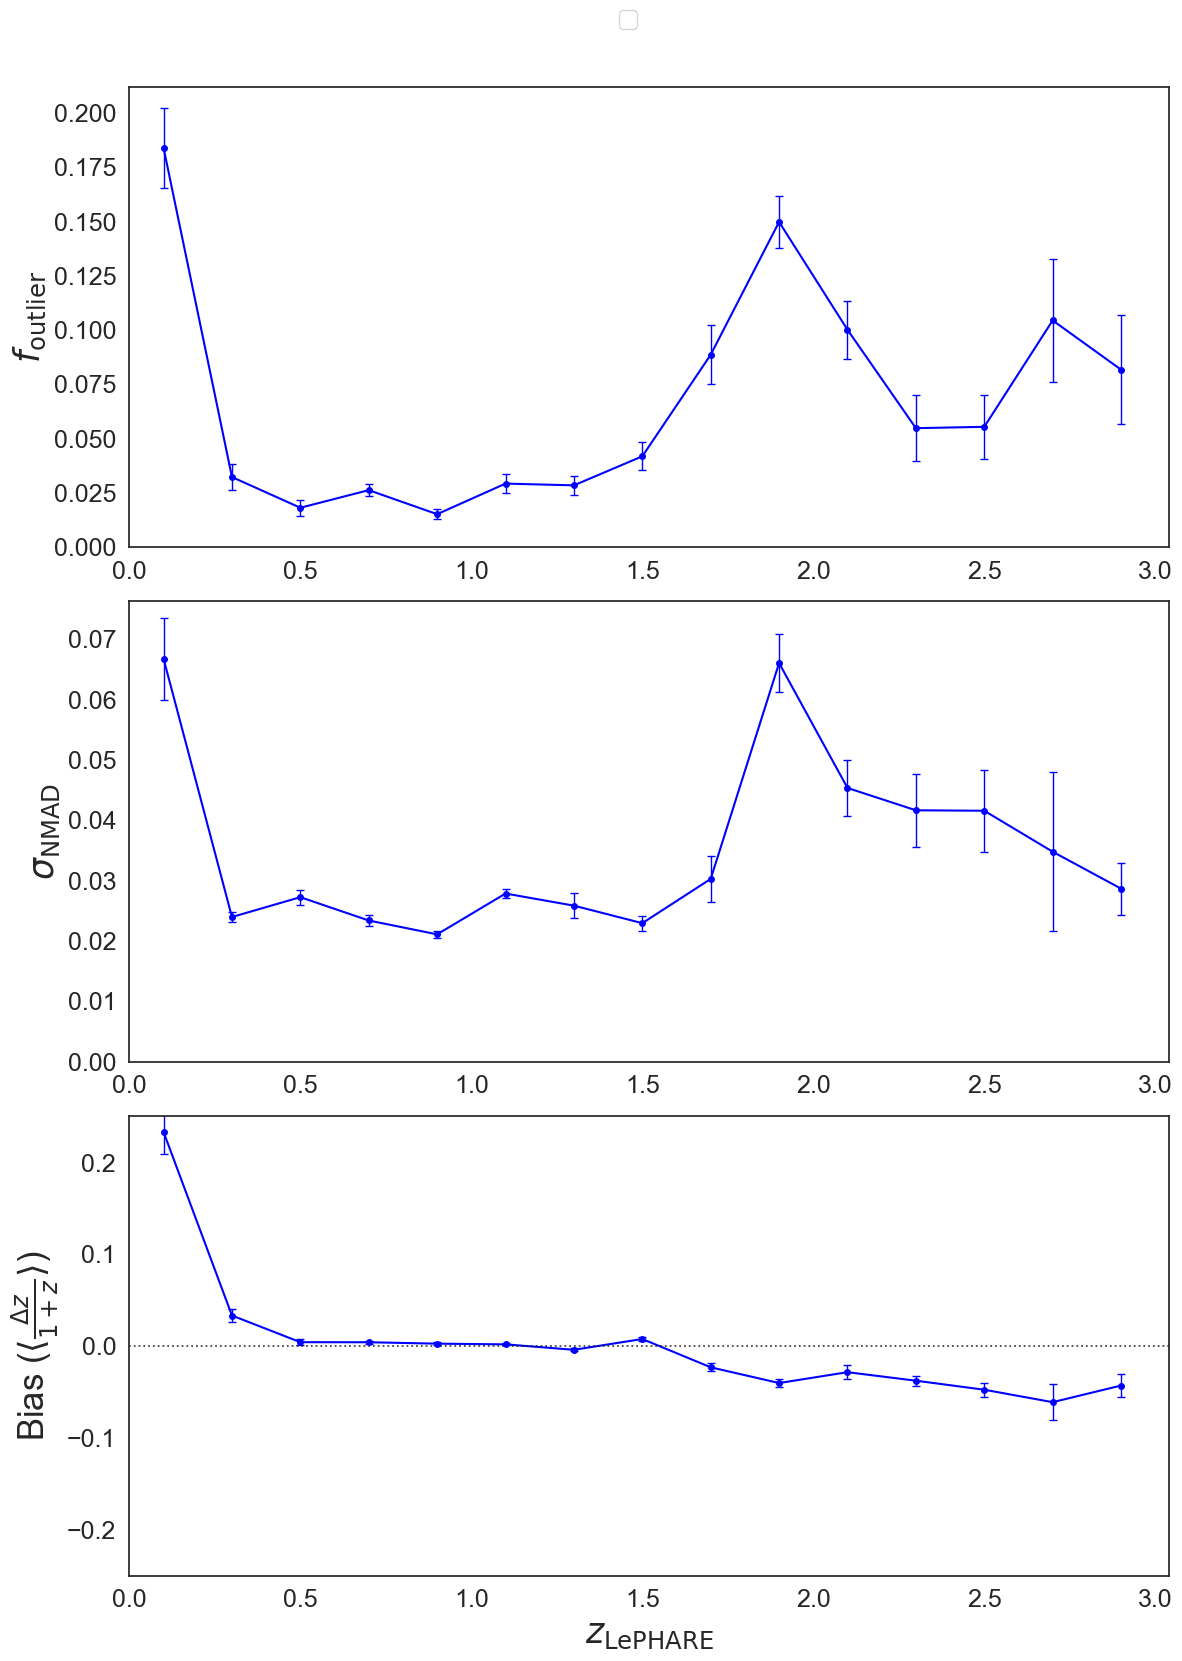

In [38]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(12,16))

    fout_ymax = 1.05*(np.max(rs_binned_results['outliers_mean'])+np.max(rs_binned_results['outliers_std']))
    nmad_ymax = 1.05*(np.max(rs_binned_results['nmads_mean'])+np.max(rs_binned_results['nmads_std']))
    bias_ymax = 1.05*(np.max(rs_binned_results['biases_mean'])+np.max(rs_binned_results['biases_std']))
    bin_centers = rs_binned_results['bin_centers']
    bin_min = 0.0

    # OUTLIERS
    #axs[0].plot(bin_centers, umap_outliers, c='blue', ls='--', label='UMAP (LePHARE-trained)')
    #axs[0].scatter(bin_centers, umap_outliers, c='blue', s=20)
    metric='outliers'
    axs[0].errorbar(bin_centers, rs_binned_results[metric+'_mean'], yerr=som_outlier_uncs, fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[0].plot(bin_centers, rs_binned_results[metric+'_mean'], c='blue', ls='-')


    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_ylim(0,None)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    #axs[1].plot(bin_centers, umap_nmads, c='blue', ls='--')
    #axs[1].scatter(bin_centers, umap_nmads, c='blue', s=20)
    metric='nmads'
    axs[1].errorbar(bin_centers, rs_binned_results[metric+'_mean'], yerr=som_nmad_uncs, fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[1].plot(bin_centers, rs_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_ylim(0,None)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    #axs[2].plot(bin_centers, umap_biases, c='blue', ls='--')
    #axs[2].scatter(bin_centers, umap_biases, c='blue', s=20)
    metric='biases'
    axs[2].errorbar(bin_centers, rs_binned_results[metric+'_mean'], yerr=som_bias_uncs, fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[2].plot(bin_centers, rs_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    axs[2].set_ylim(-bias_ymax,bias_ymax)
    axs[2].set_xlim(bin_min,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

In [39]:
som_errs = {'outliers':som_outlier_uncs, 'nmads':som_nmad_uncs, 'biases':som_bias_uncs,
            'outliers_lp':som_outlier_uncs_lp, 'nmads_lp':som_nmad_uncs_lp, 'biases_lp':som_bias_uncs_lp}

In [40]:
#with open("som_rm_errs_260511.pkl", "wb") as f:
#    pickle.dump(som_errs, f)

### Global Performance Metric Uncertainties

This section will compute the uncertainties on the full-sample performance statistics. The same approach will be used, taking the range of means divided by 2 for the uncertainties associated with our embedding choices (size, sigma, learning_rate), using 5-fold crossvalidation tests on the validation sample, and taking the standard deviation of the performance metrics obtained over 25 trials for the uncertainties associated with embedding random seed (25 seeds, spec-z train/test sets) and the finite test set (25 bootstraps of the (spec-z) test sample for one random seed run).

In [41]:
# valid contains the cell coordinates for the validation dataset for various embedding choice combinations, 
# all using the same random seed (42)
# this data is used to calculate the +/-15% uncertainties associated with choice of these
# parameters
valid

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOM_69_138_s0.85_lr0.68-1,SOM_69_138_s0.85_lr0.68-2,SOM_69_138_s0.85_lr0.8-1,SOM_69_138_s0.85_lr0.8-2,SOM_69_138_s0.85_lr0.92-1,SOM_69_138_s0.85_lr0.92-2,SOM_69_138_s1_lr0.68-1,SOM_69_138_s1_lr0.68-2,SOM_69_138_s1_lr0.8-1,SOM_69_138_s1_lr0.8-2,SOM_69_138_s1_lr0.92-1,SOM_69_138_s1_lr0.92-2,SOM_69_138_s1.15_lr0.68-1,SOM_69_138_s1.15_lr0.68-2,SOM_69_138_s1.15_lr0.8-1,SOM_69_138_s1.15_lr0.8-2,SOM_69_138_s1.15_lr0.92-1,SOM_69_138_s1.15_lr0.92-2,SOM_75_150_s0.85_lr0.68-1,SOM_75_150_s0.85_lr0.68-2,SOM_75_150_s0.85_lr0.8-1,SOM_75_150_s0.85_lr0.8-2,SOM_75_150_s0.85_lr0.92-1,SOM_75_150_s0.85_lr0.92-2,SOM_75_150_s1_lr0.68-1,SOM_75_150_s1_lr0.68-2,SOM_75_150_s1_lr0.8-1,SOM_75_150_s1_lr0.8-2,SOM_75_150_s1_lr0.92-1,SOM_75_150_s1_lr0.92-2,SOM_75_150_s1.15_lr0.68-1,SOM_75_150_s1.15_lr0.68-2,SOM_75_150_s1.15_lr0.8-1,SOM_75_150_s1.15_lr0.8-2,SOM_75_150_s1.15_lr0.92-1,SOM_75_150_s1.15_lr0.92-2,SOM_80_160_s0.85_lr0.68-1,SOM_80_160_s0.85_lr0.68-2,SOM_80_160_s0.85_lr0.8-1,SOM_80_160_s0.85_lr0.8-2,SOM_80_160_s0.85_lr0.92-1,SOM_80_160_s0.85_lr0.92-2,SOM_80_160_s1_lr0.68-1,SOM_80_160_s1_lr0.68-2,SOM_80_160_s1_lr0.8-1,SOM_80_160_s1_lr0.8-2,SOM_80_160_s1_lr0.92-1,SOM_80_160_s1_lr0.92-2,SOM_80_160_s1.15_lr0.68-1,SOM_80_160_s1.15_lr0.68-2,SOM_80_160_s1.15_lr0.8-1,SOM_80_160_s1.15_lr0.8-2,SOM_80_160_s1.15_lr0.92-1,SOM_80_160_s1.15_lr0.92-2
682744,888967,149.936450,2.785401,0,0.482169,0.008109,0.021217,0.556797,0.004353,0.008433,0.649724,0.005866,0.009340,0.815287,0.006075,0.008074,1.022175,0.009601,0.010115,1.516981,0.023160,0.015645,2.479349,0.054714,0.023929,3.181551,0.075771,0.027204,3.775385,0.057224,0.016556,5.577980,0.014766,0.003503,6.055261,0.017200,0.003780,1.5429,0,NaN,27,0.99,5,1.139000e+09,0.2,0,-19.84784,-21.53190,-22.12276,10.02579,9.89337,10.08403,10.03590,1.14004,-8.917,24.692001,24.535758,24.368177,24.121724,23.876187,23.447549,22.914156,22.643403,22.457597,22.033808,21.944668,0.156243,0.167580,0.246453,0.245537,0.428638,0.533394,0.270753,61,12,17,103,65,9,61,135,66,10,63,2,60,12,64,15,7,103,69,76,60,40,38,138,72,61,41,142,37,143,41,138,72,78,32,148,47,32,65,114,20,2,9,14,67,111,39,68,71,114,74,144,49,128
705718,915989,150.389923,1.791782,0,0.300923,0.003346,0.013912,0.391560,0.003238,0.008863,0.729946,0.004244,0.005987,0.857738,0.004264,0.005368,0.908493,0.006994,0.008269,1.053736,0.015095,0.014646,1.133205,0.028540,0.027268,1.063807,0.038095,0.040864,1.151679,0.027239,0.025818,0.553292,0.012940,0.030942,0.312715,0.016622,0.070726,0.4445,0,NaN,30,0.00,1,3.210000e+08,0.0,0,-16.35030,-17.63879,-17.70557,8.08427,8.02849,8.19774,8.06536,-1.17000,-9.212,25.203863,24.918003,24.241773,24.066614,24.004195,23.843171,23.764228,23.832843,23.746671,24.542615,25.162128,0.285860,0.676230,0.175160,0.062418,0.161025,0.078942,-0.068615,43,10,44,23,61,59,34,8,60,58,24,4,31,10,39,121,6,109,18,27,71,132,13,135,17,13,33,53,32,33,65,124,53,77,4,106,73,32,74,36,33,95,36,94,10,87,45,102,8,82,50,97,42,104
132564,175014,150.121155,1.644934,0,0.281661,0.003567,0.015858,0.294709,0.003148,0.011457,0.385362,0.004180,0.011174,0.606247,0.004185,0.007456,0.866615,0.006661,0.008258,0.800703,0.015264,0.019495,0.987316,0.013438,0.014739,0.996477,0.017941,

In [42]:
# rs_data contains the cell coordinates for the full sample in 25 different random seed runs using the "best"
# embedding choices [size, sigma, learning_rate]
# this is used to calculate the uncertainties associated with the embedding random seed and with
# the finite test set size
rs_data

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOMrs0-1,SOMrs0-2,SOMrs1-1,SOMrs1-2,SOMrs2-1,SOMrs2-2,SOMrs3-1,SOMrs3-2,SOMrs4-1,SOMrs4-2,SOMrs5-1,SOMrs5-2,SOMrs6-1,SOMrs6-2,SOMrs7-1,SOMrs7-2,SOMrs8-1,SOMrs8-2,SOMrs9-1,SOMrs9-2,SOMrs10-1,SOMrs10-2,SOMrs11-1,SOMrs11-2,SOMrs12-1,SOMrs12-2,SOMrs13-1,SOMrs13-2,SOMrs14-1,SOMrs14-2,SOMrs15-1,SOMrs15-2,SOMrs16-1,SOMrs16-2,SOMrs17-1,SOMrs17-2,SOMrs18-1,SOMrs18-2,SOMrs19-1,SOMrs19-2,SOMrs20-1,SOMrs20-2,SOMrs21-1,SOMrs21-2,SOMrs22-1,SOMrs22-2,SOMrs23-1,SOMrs23-2,SOMrs24-1,SOMrs24-2,SOMrs25-1,SOMrs25-2
7,12,150.476809,2.331511,0,0.432424,0.006043,0.017385,0.367684,0.004799,0.013929,0.539085,0.006673,0.012705,0.913139,0.006940,0.008187,0.995689,0.010382,0.011179,1.010389,0.021430,0.021652,1.176385,0.018240,0.016771,1.238664,0.023098,0.021265,1.273614,0.031158,0.026693,0.793401,0.012663,0.021113,0.623383,0.011264,0.024039,0.7070,0,NaN,30,0.00,5,9.048000e+08,0.1,1,-17.59872,-18.85507,-18.93651,8.69380,8.65194,8.74706,8.64422,-0.18369,-8.815,24.810225,24.986313,24.570856,23.998658,23.904690,23.888779,23.723626,23.667616,23.637405,24.151268,24.413112,-0.176089,0.415457,0.572198,0.093968,0.015911,0.165153,0.056011,6,4,6,25,7,135,68,52,18,145,32,52,5,135,65,142,32,120,13,82,53,38,33,61,7,27,7,20,56,14,71,94,37,35,22,135,24,129,4,80,16,11,3,41,47,26,43,16,24,89,29,35
39,73,149.468025,1.625609,0,1.057806,0.006321,0.007477,1.301316,0.007003,0.005769,2.870638,0.011023,0.003954,3.669017,0.012785,0.003763,4.321371,0.018494,0.004597,5.147967,0.045866,0.009110,5.366495,0.022263,0.004492,5.903986,0.031370,0.006063,6.666023,0.046399,0.007598,4.142945,0.036884,0.011779,4.426406,0.054762,0.016462,0.4290,0,NaN,30,0.34,9,1.609000e+09,0.2,1,-17.40718,-19.16920,-19.50800,9.06086,9.01925,9.10800,9.01447,0.08064,-8.977,23.838985,23.614043,22.755054,22.488626,22.310946,22.120911,22.075773,21.972137,21.840333,22.356727,22.284872,0.224942,0.858989,0.266428,0.177680,0.190035,0.045137,0.103637,31,49,49,90,9,75,74,121,41,84,37,123,24,22,20,72,74,79,51,45,20,121,8,111,22,6,27,119,36,0,64,80,71,146,46,37,7,9,18,80,67,96,65,32,61,61,11,135,62,85,67,25
40,74,150.488035,1.875422,0,0.941051,0.003713,0.004937,1.032136,0.004159,0.004320,1.066959,0.005443,0.005254,1.123350,0.005748,0.005525,1.208387,0.008979,0.007981,1.734654,0.019518,0.011504,2.413042,0.014805,0.006643,2.547439,0.017875,0.008007,2.257407,0.024673,0.011931,2.951406,0.013003,0.005829,3.054308,0.014661,0.006387,1.5087,0,NaN,29,2.23,10,9.048000e+08,0.1,1,-20.37010,-21.24365,-21.42674,9.49598,9.44923,9.54398,9.50023,0.99993,-8.536,23.965967,23.865658,23.829631,23.773713,23.694485,23.301968,22.943588,22.884741,23.015975,22.724928,22.687718,0.100310,0.036027,0.055918,0.079228,0.392517,0.358380,0.058847,0,146,66,147,3,106,2,7,0,4,50,134,34,56,65,18,46,116,8,0,44,142,74,148,13,114,3,93,24,133,43,129,35,98,39,6,13,104,68,131,55,140,5,122,63,130,5,90,20,5,41,3
46,85,150.476436,2.334178,0,0.685237,0.005227,0.009492,0.669388,0.004202,0.006701,0.744438,0.005884,0.008114,1.119968,0.005803,0.005582,1.484551,0.008772,0.006335,1.619744,0.018884,0.011903,1.782537,0.015855,0.009621,1.867551,0.020190,0.012329,2.274360,0.027033,0.012969,2.573668,0.012908,0.006634,1.992754,0.011691,0.007805,1.0800,0,NaN,29,2.1

In [43]:
#sizes = [(46,92), (50,100), (54,108)]
sizes = [(69,138), (75,150), (80,160)]
sigmas = [0.85, 1, 1.15]
learning_rates = [0.68, 0.8, 0.92]
n_embeddings = 25
n_boots = 25

In [44]:
# UNCERTAINTY DUE TO SOM SIZE CHOICE
sizeg_sets = {str(size): [0] for size in sizes}
sizeg_results = {str(size): [0] for size in sizes}
sizeg_outliers_mean = []
sizeg_nmads_mean = []
sizeg_biases_mean = []

sigma, learning_rate = 1, 0.8
for size in sizes:
    sizeg_results[str(size)], sizeg_sets[str(size)] = umapz2.crossvalidate_global(folds=5, data=valid, nn=size[0], 
                            map='SOM_'+str(size[0])+'_'+str(size[1])+'_s'+str(sigma)+'_lr'+str(learning_rate), tv='lp_photoz', 
                            dim=2, rematch=True)
    sizeg_outliers_mean.append(sizeg_results[str(size)]['outliers_mean'])
    sizeg_nmads_mean.append(sizeg_results[str(size)]['nmads_mean'])
    sizeg_biases_mean.append(sizeg_results[str(size)]['biases_mean'])

unc_size_outliers = (np.asarray(sizeg_outliers_mean).max(axis=0) - np.asarray(sizeg_outliers_mean).min(axis=0))/2
unc_size_nmads = (np.asarray(sizeg_nmads_mean).max(axis=0) - np.asarray(sizeg_nmads_mean).min(axis=0))/2
unc_size_biases = (np.asarray(sizeg_biases_mean).max(axis=0) - np.asarray(sizeg_biases_mean).min(axis=0))/2

In [46]:
# UNCERTAINTY DUE TO SOM SIGMA CHOICE
sigmag_sets = {str(sigma): [0] for sigma in sigmas}
sigmag_results = {str(sigma): [0] for sigma in sigmas}
sigmag_outliers_mean = []
sigmag_nmads_mean = []
sigmag_biases_mean = []

size, learning_rate = (75,150), 0.8
for sigma in sigmas:
    sigmag_results[str(sigma)], sigmag_sets[str(sigma)] = umapz2.crossvalidate_global(folds=5, data=valid, nn=size[0], 
                            map='SOM_'+str(size[0])+'_'+str(size[1])+'_s'+str(sigma)+'_lr'+str(learning_rate), 
                            tv='lp_photoz', dim=2, rematch=True)
    sigmag_outliers_mean.append(sigmag_results[str(sigma)]['outliers_mean'])
    sigmag_nmads_mean.append(sigmag_results[str(sigma)]['nmads_mean'])
    sigmag_biases_mean.append(sigmag_results[str(sigma)]['biases_mean'])

unc_sigma_outliers = (np.asarray(sigmag_outliers_mean).max(axis=0) - np.asarray(sigmag_outliers_mean).min(axis=0))/2
unc_sigma_nmads = (np.asarray(sigmag_nmads_mean).max(axis=0) - np.asarray(sigmag_nmads_mean).min(axis=0))/2
unc_sigma_biases = (np.asarray(sigmag_biases_mean).max(axis=0) - np.asarray(sigmag_biases_mean).min(axis=0))/2

In [47]:
# UNCERTAINTY DUE TO SOM LEARNING_RATE CHOICE
learning_rate_g_sets = {str(learning_rate): [0] for learning_rate in learning_rates}
learning_rate_g_results = {str(learning_rate): [0] for learning_rate in learning_rates}
learning_rate_g_outliers_mean = []
learning_rate_g_nmads_mean = []
learning_rate_g_biases_mean = []

sigma, size = 1, (75,150)
for learning_rate in learning_rates:
    learning_rate_g_results[str(learning_rate)], learning_rate_g_sets[str(learning_rate)] = umapz2.crossvalidate_global(folds=5, data=valid, nn=size[0], 
                            map='SOM_'+str(size[0])+'_'+str(size[1])+'_s'+str(sigma)+'_lr'+str(learning_rate), 
                            tv='lp_photoz', dim=2, rematch=True)
    learning_rate_g_outliers_mean.append(learning_rate_g_results[str(learning_rate)]['outliers_mean'])
    learning_rate_g_nmads_mean.append(learning_rate_g_results[str(learning_rate)]['nmads_mean'])
    learning_rate_g_biases_mean.append(learning_rate_g_results[str(learning_rate)]['biases_mean'])

unc_learning_rate_outliers = (np.asarray(learning_rate_g_outliers_mean).max(axis=0) - np.asarray(learning_rate_g_outliers_mean).min(axis=0))/2
unc_learning_rate_nmads = (np.asarray(learning_rate_g_nmads_mean).max(axis=0) - np.asarray(learning_rate_g_nmads_mean).min(axis=0))/2
unc_learning_rate_biases = (np.asarray(learning_rate_g_biases_mean).max(axis=0) - np.asarray(learning_rate_g_biases_mean).min(axis=0))/2

In [48]:
print(unc_size_outliers)
print(unc_size_nmads)
print(unc_size_biases)
print()
print(unc_sigma_outliers)
print(unc_sigma_nmads)
print(unc_sigma_biases)
print()
print(unc_learning_rate_outliers)
print(unc_learning_rate_nmads)
print(unc_learning_rate_biases)

0.0005872431988854857
0.00022091920382294288
0.0006754146613690616

0.0011742597734711244
0.0003189408659942713
0.0005554305836005559

0.0008980286071431989
0.00012369622883482562
0.001224638018957567


In [49]:
unc_size_outliers

0.0005872431988854857

In [50]:
rs_results

{'outliers_mean': 0.04303453070128127,
 'outliers_std': 0.0006192814233915629,
 'nmads_mean': 0.027563366820037596,
 'nmads_std': 0.0001294856955638557,
 'biases_mean': 0.008847189917113526,
 'biases_std': 0.000433638117985298,
 'outliers_mean_lp': 0.027865749486690843,
 'outliers_std_lp': 0.0005385134661148845,
 'nmads_mean_lp': 0.02471845550102417,
 'nmads_std_lp': 0.00015982944745616972,
 'biases_mean_lp': 0.006359610726177796,
 'biases_std_lp': 0.00038921192007012375}

In [51]:
boots_results

{'outliers_mean': 0.04340105234139968,
 'outliers_std': 0.0006606171579626494,
 'nmads_mean': 0.027699620449980582,
 'nmads_std': 0.00011289319982124904,
 'stdevs_mean': 0.1806921975861717,
 'stdevs_std': 0.003851459814637134,
 'biases_mean': 0.009219107226752175,
 'biases_std': 0.0006672490296271794,
 'outliers_mean_lp': 0.027251567125717645,
 'outliers_std_lp': 0.00037865172812651484,
 'nmads_mean_lp': 0.02473744206305573,
 'nmads_std_lp': 0.00018568314699286665,
 'stdevs_mean_lp': 0.1411101594322635,
 'stdevs_std_lp': 0.0034977409972921677,
 'biases_mean_lp': 0.006206348488414062,
 'biases_std_lp': 0.00042965699133326054}

In [52]:
metric='outliers'
som_outlier_unc = np.sqrt(unc_size_outliers**2 + unc_sigma_outliers**2 + unc_learning_rate_outliers**2 + (rs_results[metric+'_std'])**2 + (boots_results[metric+'_std'])**2)
som_outlier_unc_lp = np.sqrt(unc_size_outliers**2 + unc_sigma_outliers**2 + unc_learning_rate_outliers**2 + (rs_results[metric+'_std_lp'])**2 + (boots_results[metric+'_std_lp'])**2)
metric='nmads'
som_nmad_unc = np.sqrt(unc_size_nmads**2 + unc_sigma_nmads**2 + unc_learning_rate_nmads**2 + (rs_results[metric+'_std'])**2 + (boots_results[metric+'_std'])**2)
som_nmad_unc_lp = np.sqrt(unc_size_nmads**2 + unc_sigma_nmads**2 + unc_learning_rate_nmads**2 + (rs_results[metric+'_std_lp'])**2 + (boots_results[metric+'_std_lp'])**2)
metric='biases'
som_bias_unc = np.sqrt(unc_size_biases**2 + unc_sigma_biases**2 + unc_learning_rate_biases**2 + (rs_results[metric+'_std'])**2 + (boots_results[metric+'_std'])**2)
som_bias_unc_lp = np.sqrt(unc_size_biases**2 + unc_sigma_biases**2 + unc_learning_rate_biases**2 + (rs_results[metric+'_std_lp'])**2 + (boots_results[metric+'_std_lp'])**2)


### Global Stats w/ Uncertainties

In [53]:
print('SOM-z (rematch, spec-z-trained) f_outlier: '+str(np.round(rs_results['outliers_mean'],4))+' +/- '+str(np.round(som_outlier_unc, 4)))
print('SOM-z (rematch, spec-z-trained) NMAD: '+str(np.round(rs_results['nmads_mean'],4))+' +/- '+str(np.round(som_nmad_unc, 4)))
print('SOM-z (rematch, spec-z-trained) bias: '+str(np.round(rs_results['biases_mean'],4))+' +/- '+str(np.round(som_bias_unc, 4)))

SOM-z (rematch, spec-z-trained) f_outlier: 0.043 +/- 0.0018
SOM-z (rematch, spec-z-trained) NMAD: 0.0276 +/- 0.0004
SOM-z (rematch, spec-z-trained) bias: 0.0088 +/- 0.0017


In [54]:
print('SOM-z (rematch, LePHARE-trained) f_outlier: '+str(np.round(rs_results['outliers_mean_lp'],4))+' +/- '+str(np.round(som_outlier_unc_lp, 4)))
print('SOM-z (rematch, LePHARE-trained) NMAD: '+str(np.round(rs_results['nmads_mean_lp'],4))+' +/- '+str(np.round(som_nmad_unc_lp, 4)))
print('SOM-z (rematch, LePHARE-trained) bias: '+str(np.round(rs_results['biases_mean_lp'],4))+' +/- '+str(np.round(som_bias_unc_lp, 4)))

SOM-z (rematch, LePHARE-trained) f_outlier: 0.0279 +/- 0.0017
SOM-z (rematch, LePHARE-trained) NMAD: 0.0247 +/- 0.0005
SOM-z (rematch, LePHARE-trained) bias: 0.0064 +/- 0.0016


In [77]:
somrm_global = {
'specz_trained':{
    'f_outlier':{
        'mean':rs_results['outliers_mean'],
        'unc':som_outlier_unc,
        'unc_size':unc_size_outliers,
        'unc_sigma':unc_sigma_outliers,
        'unc_learning_rate':unc_learning_rate_outliers,
        'unc_rs':rs_results['outliers_std'],
        'unc_boots':boots_results['outliers_std']
    },
    'nmad':{
        'mean':rs_results['nmads_mean'],
        'unc':som_nmad_unc,
        'unc_size':unc_size_nmads,
        'unc_sigma':unc_sigma_nmads,
        'unc_learning_rate':unc_learning_rate_nmads,
        'unc_rs':rs_results['nmads_std'],
        'unc_boots':boots_results['nmads_std']        
    },
    'bias':{
        'mean':rs_results['biases_mean'],
        'unc':som_bias_unc,
        'unc_size':unc_size_biases,
        'unc_sigma':unc_sigma_biases,
        'unc_learning_rate':unc_learning_rate_biases,
        'unc_rs':rs_results['biases_std'],
        'unc_boots':boots_results['biases_std'] 
    },

},
'LePHARE_trained':{
    'f_outlier':{
        'mean':rs_results['outliers_mean_lp'],
        'unc':som_outlier_unc_lp,
        'unc_size':unc_size_outliers,
        'unc_sigma':unc_sigma_outliers,
        'unc_learning_rate':unc_learning_rate_outliers,
        'unc_rs':rs_results['outliers_std_lp'],
        'unc_boots':boots_results['outliers_std_lp']
    },
    'nmad':{
        'mean':rs_results['nmads_mean_lp'],
        'unc':som_nmad_unc_lp,
        'unc_size':unc_size_nmads,
        'unc_sigma':unc_sigma_nmads,
        'unc_learning_rate':unc_learning_rate_nmads,
        'unc_rs':rs_results['nmads_std_lp'],
        'unc_boots':boots_results['nmads_std_lp']        
    },
    'bias':{
        'mean':rs_results['biases_mean_lp'],
        'unc':som_bias_unc_lp,
        'unc_size':unc_size_biases,
        'unc_sigma':unc_sigma_biases,
        'unc_learning_rate':unc_learning_rate_biases,
        'unc_rs':rs_results['biases_std_lp'],
        'unc_boots':boots_results['biases_std_lp'] 
    },

}
}

In [78]:
somrm_global 

{'specz_trained': {'f_outlier': {'mean': 0.04303453070128127,
   'unc': 0.0018303334341670636,
   'unc_size': 0.0005872431988854857,
   'unc_sigma': 0.0011742597734711244,
   'unc_learning_rate': 0.0008980286071431989,
   'unc_rs': 0.0006192814233915629,
   'unc_boots': 0.0006606171579626494},
  'nmad': {'mean': 0.027563366820037596,
   'unc': 0.0004419736955616615,
   'unc_size': 0.00022091920382294288,
   'unc_sigma': 0.0003189408659942713,
   'unc_learning_rate': 0.00012369622883482562,
   'unc_rs': 0.0001294856955638557,
   'unc_boots': 0.00011289319982124904},
  'bias': {'mean': 0.008847189917113526,
   'unc': 0.001702260162365229,
   'unc_size': 0.0006754146613690616,
   'unc_sigma': 0.0005554305836005559,
   'unc_learning_rate': 0.001224638018957567,
   'unc_rs': 0.000433638117985298,
   'unc_boots': 0.0006672490296271794}},
 'LePHARE_trained': {'f_outlier': {'mean': 0.027865749486690843,
   'unc': 0.0017215022085020778,
   'unc_size': 0.0005872431988854857,
   'unc_sigma': 0.00

In [79]:
#with open("somrm_global_260511.pkl", "wb") as f:
#    pickle.dump(somrm_global, f)

In [1]:
somrm_global = {'specz_trained': {'f_outlier': {'mean': 0.04303453070128127,
   'unc': 0.0018303334341670636,
   'unc_size': 0.0005872431988854857,
   'unc_sigma': 0.0011742597734711244,
   'unc_learning_rate': 0.0008980286071431989,
   'unc_rs': 0.0006192814233915629,
   'unc_boots': 0.0006606171579626494},
  'nmad': {'mean': 0.027563366820037596,
   'unc': 0.0004419736955616615,
   'unc_size': 0.00022091920382294288,
   'unc_sigma': 0.0003189408659942713,
   'unc_learning_rate': 0.00012369622883482562,
   'unc_rs': 0.0001294856955638557,
   'unc_boots': 0.00011289319982124904},
  'bias': {'mean': 0.008847189917113526,
   'unc': 0.001702260162365229,
   'unc_size': 0.0006754146613690616,
   'unc_sigma': 0.0005554305836005559,
   'unc_learning_rate': 0.001224638018957567,
   'unc_rs': 0.000433638117985298,
   'unc_boots': 0.0006672490296271794}},
 'LePHARE_trained': {'f_outlier': {'mean': 0.027865749486690843,
   'unc': 0.0017215022085020778,
   'unc_size': 0.0005872431988854857,
   'unc_sigma': 0.0011742597734711244,
   'unc_learning_rate': 0.0008980286071431989,
   'unc_rs': 0.0005385134661148845,
   'unc_boots': 0.00037865172812651484},
  'nmad': {'mean': 0.02471845550102417,
   'unc': 0.0004752399509702602,
   'unc_size': 0.00022091920382294288,
   'unc_sigma': 0.0003189408659942713,
   'unc_learning_rate': 0.00012369622883482562,
   'unc_rs': 0.00015982944745616972,
   'unc_boots': 0.00018568314699286665},
  'bias': {'mean': 0.006359610726177796,
   'unc': 0.0016126119881712633,
   'unc_size': 0.0006754146613690616,
   'unc_sigma': 0.0005554305836005559,
   'unc_learning_rate': 0.001224638018957567,
   'unc_rs': 0.00038921192007012375,
   'unc_boots': 0.00042965699133326054}}}

In [2]:
trains = 'LePHARE', 'specz'
metrics = 'f_outlier', 'nmad', 'bias'

for train in trains:
    for metric in metrics:
        data = somrm_global[train+'_trained'][metric].copy()
        sorted_data = dict(sorted(data.items(), key=lambda item: item[1]))
        print(train + ' ' + metric + ':', list(sorted_data.keys()))

LePHARE f_outlier: ['unc_boots', 'unc_rs', 'unc_size', 'unc_learning_rate', 'unc_sigma', 'unc', 'mean']
LePHARE nmad: ['unc_learning_rate', 'unc_rs', 'unc_boots', 'unc_size', 'unc_sigma', 'unc', 'mean']
LePHARE bias: ['unc_rs', 'unc_boots', 'unc_sigma', 'unc_size', 'unc_learning_rate', 'unc', 'mean']
specz f_outlier: ['unc_size', 'unc_rs', 'unc_boots', 'unc_learning_rate', 'unc_sigma', 'unc', 'mean']
specz nmad: ['unc_boots', 'unc_learning_rate', 'unc_rs', 'unc_size', 'unc_sigma', 'unc', 'mean']
specz bias: ['unc_rs', 'unc_sigma', 'unc_boots', 'unc_size', 'unc_learning_rate', 'unc', 'mean']


^^^
in both training cases, sigma largest contributor to f_out and nmad, learning rate largest contributor to bias

rs is now the second smallest contributor in LP f_out and nmad and specz f_out, and smallest in bias in both training cases. rs only larger than boots 2/6 now (LP f_out and specz nmad).

boots is smallest for LP f_out and specz nmad

size smallest for specz f_out, learning rate smallest for LP nmad

size seecond largest contributor for nmad and bias in both cases

Text(0.5, 0.98, 'Global Performance with Uncertainties (spec-z-trained case)')

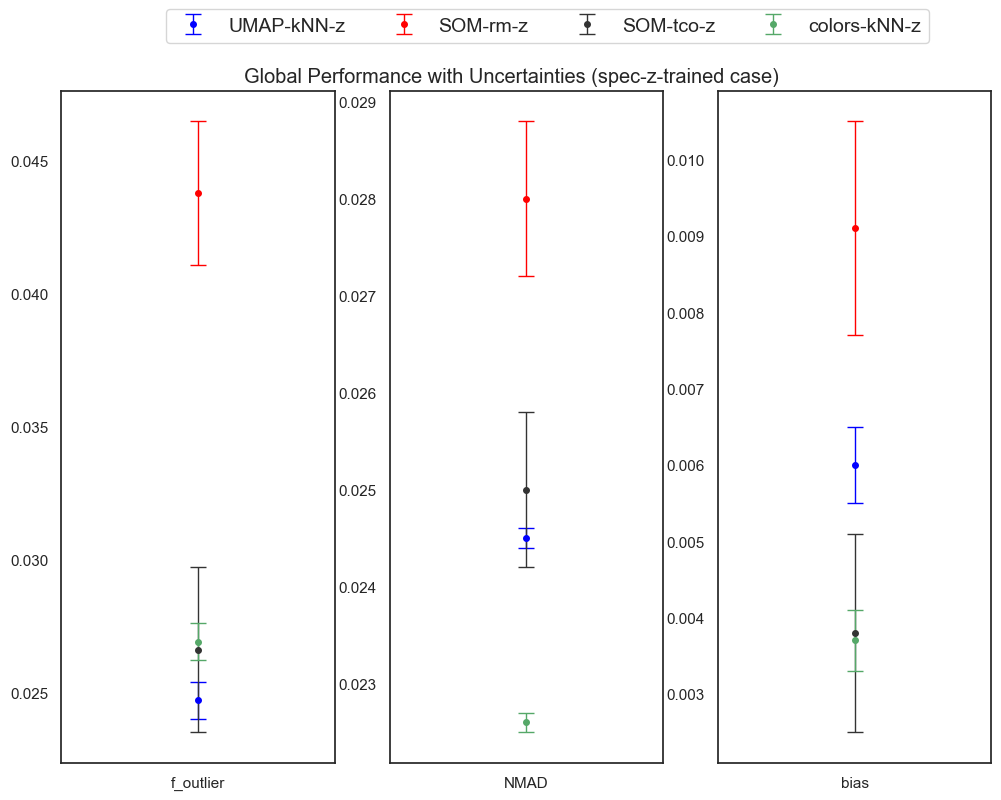

In [29]:
xs = ['f_outlier', 'NMAD', 'bias']
ys1 = [0.0247, 0.0245, 0.0060] # UMAP
yerrs1 = [0.0007, 0.0001, 0.0005]
ys2 = [0.0438, 0.028, 0.0091] # SOM-rm
yerrs2 = [0.0027, 0.0008, 0.0014]
ys3 = [0.0266, 0.025, 0.0038] # SOM-tco
yerrs3 = [0.0031, 0.0008, 0.0013]
ys4 = [0.0269, 0.0226, 0.0037] # colors
yerrs4 = [0.0007, 0.0001, 0.0004]

cs = 6
fig, axs = plt.subplots(1, 3, figsize=(12,8))
for i, x in enumerate(xs):
    if i ==0:
        axs[i].errorbar(x, ys1[i], yerr=yerrs1[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='blue', label='UMAP-kNN-z')
        axs[i].errorbar(x, ys2[i], yerr=yerrs2[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='red', label='SOM-rm-z')
        axs[i].errorbar(x, ys3[i], yerr=yerrs3[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='0.2', label='SOM-tco-z')
        axs[i].errorbar(x, ys4[i], yerr=yerrs4[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='g', label='colors-kNN-z')
    else:
        axs[i].errorbar(x, ys1[i], yerr=yerrs1[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='blue')
        axs[i].errorbar(x, ys2[i], yerr=yerrs2[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='red')
        axs[i].errorbar(x, ys3[i], yerr=yerrs3[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='0.2')
        axs[i].errorbar(x, ys4[i], yerr=yerrs4[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='g')

#fig.legend(bbox_to_anchor=(0.9,0.88), fontsize=14)
fig.subplots_adjust(top=0.95)
fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                    ncols=4, borderaxespad=0., fontsize=14)
fig.suptitle('Global Performance with Uncertainties (spec-z-trained case)')

Text(0.5, 0.98, 'Global Performance with Uncertainties (spec-z-trained case)')

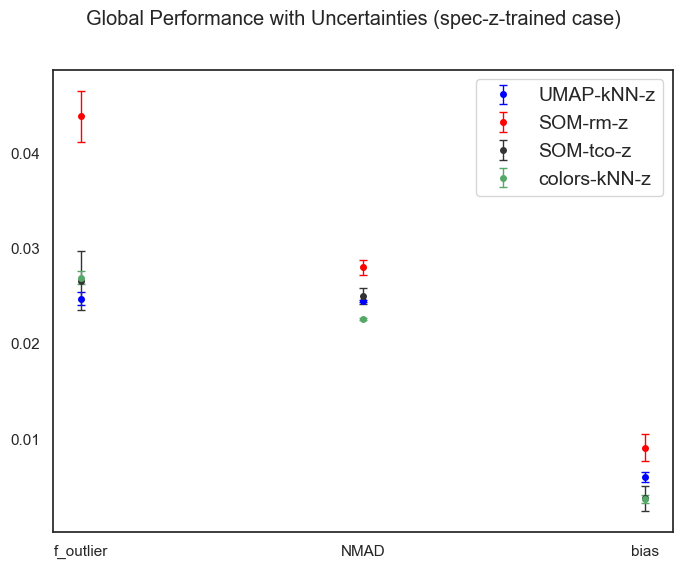

In [25]:
xs = ['f_outlier', 'NMAD', 'bias']
ys1 = [0.0247, 0.0245, 0.0060] # UMAP
yerrs1 = [0.0007, 0.0001, 0.0005]
ys2 = [0.0438, 0.028, 0.0091] # SOM-rm
yerrs2 = [0.0027, 0.0008, 0.0014]
ys3 = [0.0266, 0.025, 0.0038] # SOM-tco
yerrs3 = [0.0031, 0.0008, 0.0013]
ys4 = [0.0269, 0.0226, 0.0037] # colors
yerrs4 = [0.0007, 0.0001, 0.0004]

fig, axs = plt.subplots(1, 1, figsize=(8,6))
axs.errorbar(xs, ys1, yerr=yerrs1, fmt='o', capsize=3,
                    lw=1, ms=4, c='blue', label='UMAP-kNN-z')
axs.errorbar(xs, ys2, yerr=yerrs2, fmt='o', capsize=3,
                    lw=1, ms=4, c='red', label='SOM-rm-z')
axs.errorbar(xs, ys3, yerr=yerrs3, fmt='o', capsize=3,
                    lw=1, ms=4, c='0.2', label='SOM-tco-z')
axs.errorbar(xs, ys4, yerr=yerrs4, fmt='o', capsize=3,
                    lw=1, ms=4, c='g', label='colors-kNN-z')

fig.legend(bbox_to_anchor=(0.9,0.88), fontsize=14)
fig.suptitle('Global Performance with Uncertainties (spec-z-trained case)')

Text(0.5, 0.98, 'Global Performance with Uncertainties (LePHARE-trained case)')

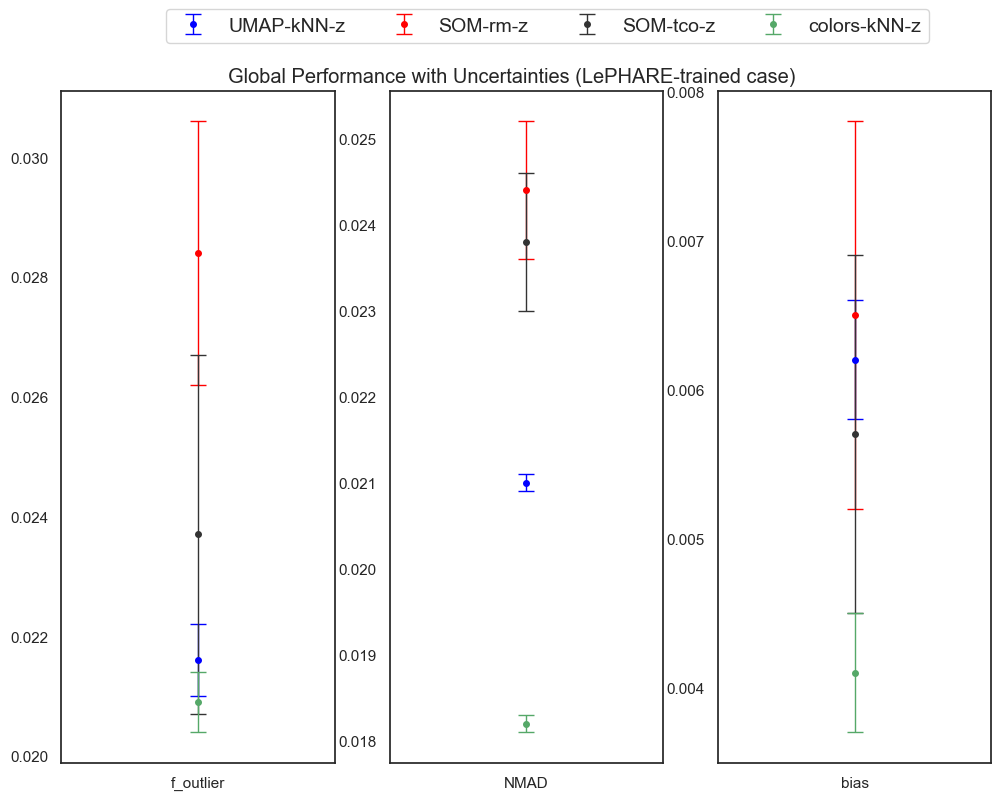

In [28]:
xs = ['f_outlier', 'NMAD', 'bias']
ys1 = [0.0216, 0.021, 0.0062] # UMAP
yerrs1 = [0.0006, 0.0001, 0.0004]
ys2 = [0.0284, 0.0244, 0.0065] # SOM-rm
yerrs2 = [0.0022, 0.0008, 0.0013]
ys3 = [0.0237, 0.0238, 0.0057] # SOM-tco
yerrs3 = [0.0030, 0.0008, 0.0012]
ys4 = [0.0209, 0.0182, 0.0041] # colors
yerrs4 = [0.0005, 0.0001, 0.0004]

cs = 6
fig, axs = plt.subplots(1, 3, figsize=(12,8))
for i, x in enumerate(xs):
    if i ==0:
        axs[i].errorbar(x, ys1[i], yerr=yerrs1[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='blue', label='UMAP-kNN-z')
        axs[i].errorbar(x, ys2[i], yerr=yerrs2[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='red', label='SOM-rm-z')
        axs[i].errorbar(x, ys3[i], yerr=yerrs3[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='0.2', label='SOM-tco-z')
        axs[i].errorbar(x, ys4[i], yerr=yerrs4[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='g', label='colors-kNN-z')
    else:
        axs[i].errorbar(x, ys1[i], yerr=yerrs1[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='blue')
        axs[i].errorbar(x, ys2[i], yerr=yerrs2[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='red')
        axs[i].errorbar(x, ys3[i], yerr=yerrs3[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='0.2')
        axs[i].errorbar(x, ys4[i], yerr=yerrs4[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='g')

#fig.legend(bbox_to_anchor=(0.9,0.88), fontsize=14)
fig.subplots_adjust(top=0.95)
fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                    ncols=4, borderaxespad=0., fontsize=14)
fig.suptitle('Global Performance with Uncertainties (LePHARE-trained case)')

Text(0.5, 0.98, 'Global Performance with Uncertainties (LePHARE-trained case)')

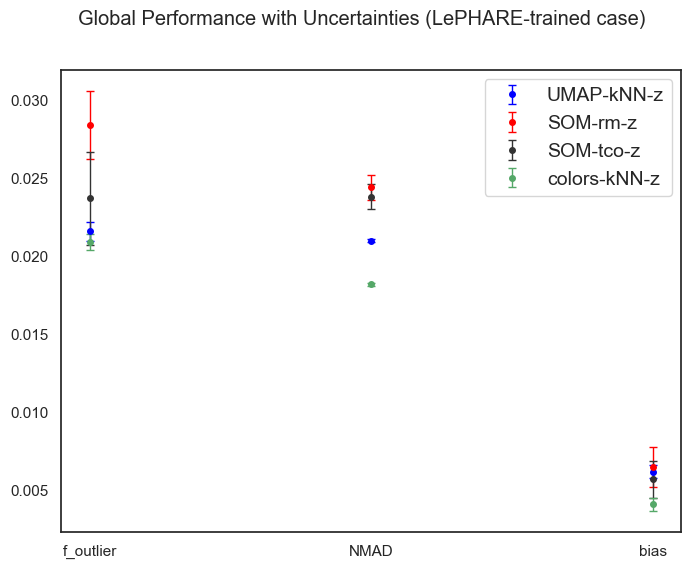

In [6]:
xs = ['f_outlier', 'NMAD', 'bias']
ys1 = [0.0216, 0.021, 0.0062] # UMAP
yerrs1 = [0.0006, 0.0001, 0.0004]
ys2 = [0.0284, 0.0244, 0.0065] # SOM-rm
yerrs2 = [0.0022, 0.0008, 0.0013]
ys3 = [0.0237, 0.0238, 0.0057] # SOM-tco
yerrs3 = [0.0030, 0.0008, 0.0012]
ys4 = [0.0209, 0.0182, 0.0041] # colors
yerrs4 = [0.0005, 0.0001, 0.0004]

fig, axs = plt.subplots(1, 1, figsize=(8,6))
axs.errorbar(xs, ys1, yerr=yerrs1, fmt='o', capsize=3,
                    lw=1, ms=4, c='blue', label='UMAP-kNN-z')
axs.errorbar(xs, ys2, yerr=yerrs2, fmt='o', capsize=3,
                    lw=1, ms=4, c='red', label='SOM-rm-z')
axs.errorbar(xs, ys3, yerr=yerrs3, fmt='o', capsize=3,
                    lw=1, ms=4, c='0.2', label='SOM-tco-z')
axs.errorbar(xs, ys4, yerr=yerrs4, fmt='o', capsize=3,
                    lw=1, ms=4, c='g', label='colors-kNN-z')

fig.legend(bbox_to_anchor=(0.9,0.88), fontsize=14)
fig.suptitle('Global Performance with Uncertainties (LePHARE-trained case)')